# DATA 2010 Project — Olympics (1896–2024)


### Student Information
- **Prince Kanani** — **8029853**
- **Joshua Mudiwa** — **7954458**

### Course Information
- **Course:** DATA 2010
- **Term:** Winter 2026
- **Instructor:** Lei Ding

### Dataset
- **Dataset name:** Olympic Summer and Winter Games (1896–2024)
- **Source:** Kaggle
- **Link:** https://www.kaggle.com/datasets/magicchris/olympic-summer-and-winter-games-1896-2024

### Project Overview
This notebook analyzes long-run Olympic patterns in athlete participation, medal outcomes, country performance, and medal probability.  
The project is organized around three main research questions:

### Research Question 1
How do medal outcomes vary by age group and sex, and how did gender parity and typical medal-winning ages change across decades?

### Research Question 2
To what extent is country participation size associated with event-medal counts, and how does this relationship shape medal efficiency and Olympic dominance?

### Research Question 3
What factors most influence an athlete's probability of winning a medal, and to what extent does country/team membership contribute to medal probability after accounting for athlete characteristics?

### How to Run This Notebook
1. Make sure the dataset CSV file is stored in the correct folder.
2. Run the notebook **from top to bottom**.
3. Do **not** skip earlier cells, because later sections depend on variables created earlier.
4. If the kernel restarts, rerun all cells in order.

### Practical reading guide

- **RQ1 cells** answer questions about **age group**, **sex**, **gender parity**, and **peak medal-winning age**.
- **RQ2 cells** answer questions about **country participation size**, **event-medal counts**, **efficiency**, **dominance**, and **regression fit**.
- **RQ3 cells** answer questions about **athlete-level medal probability** and whether **country/team membership** improves logistic-regression prediction.

## Notebook Flow and Section Map

This notebook is designed to run in the following order:

### Section 1 — Loading the data
- **Cells 1A–1B**
- Load the raw dataset and create the initial working dataframe.

### Section 2 — Data types, variable types, and granularity
- **Cells 2A–2C**
- Inspect data types, variable roles, and what each row represents.

### Section 3 — Dataset inspection
- **Cells 3A–3D**
- Check shape, columns, sample rows, and core summaries.

### Section 4 — Missing values and outliers
- **Cells 4A–4C**
- Inspect missingness and flag suspicious ages.

### Section 5 — Comprehensive facts and inspections
- **Cells 5A–5F**
- Produce broad descriptive facts and quick summaries.

### Section 6 — Data cleaning
- **Cells 6A–6E**
- Standardize values, remove duplicates, clean country labels, and create the cleaned working dataset.

### Section 7 — Feature engineering
- **Cells 7A–7E**
- Create decade, won-medal flag, medal points, age groups, cleaned sport labels, and grouped sport categories.

### Section 8 — Interesting facts and quick plots
- **Cells 8A–8F**
- Produce early descriptive summaries before the main research questions.

### Research Question 1
- **RQ1(a), RQ1(b), RQ1(c)**
- Age group, sex composition, gender parity, and peak medal-winning age.

### Research Question 2
- **RQ2(a), RQ2(b), RQ2(c)**
- Participation size, event medals, efficiency, and dominance.

### Research Question 3
- **RQ3(a), RQ3(b)**
- Athlete-level medal probability and country/team-adjusted logistic regression.

### Appendix
- Supplementary figures and tables that support, but do not drive, the main conclusions.


## 1) Loading the data

In [2]:
# 1A) Imports and notebook settings
# --------------------------------
# This cell imports the main libraries used throughout the notebook
# and creates output folders for figures and tables.

In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
import statsmodels.formula.api as smf

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)

os.makedirs("figures", exist_ok=True)
os.makedirs("outputs", exist_ok=True)

print("Imports loaded and output folders ready.")


Imports loaded and output folders ready.


In [4]:
### Load the CSV 
# Update this path to the actual location on your working device
path = r"C:\Users\joshu\Documents\Uni Work\Winter 2026\Data 2010\FInal Project\olympics_1896_2024.csv"

df_raw = pd.read_csv(path, low_memory=False)
print("Loaded shape (rows, cols):", df_raw.shape)

df = df_raw.copy()
df.head()


Loaded shape (rows, cols): (290697, 8)


,sex,age,team,year,season,sports,event,medal
0,M,72,Great Britain,1948,Summer,Art Competitions,"Art Competitions Mixed Sculpturing, Medals And...",NaN
1,M,72,Latvia,1936,Summer,Art Competitions,"Art Competitions Mixed Painting, Paintings",NaN
2,M,72,Austria,1936,Summer,Equestrianism,"Equestrianism Men's Dressage, Individual",NaN
3,M,72,Austria,1936,Summer,Equestrianism,"Equestrianism Men's Dressage, Team",NaN
4,M,72,Netherlands,1928,Summer,Art Competitions,"Art Competitions Mixed Painting, Paintings",NaN


## 2) Data types, variable types, and granularity

In [5]:
### 2A) Pandas data types + missing counts
dtype_table = pd.DataFrame({
    "column": df.columns,
    "pandas_dtype": [df[c].dtype for c in df.columns],
    "missing_count": [df[c].isna().sum() for c in df.columns]
}).sort_values("column")

dtype_table


,column,pandas_dtype,missing_count
1,age,int64,0
6,event,str,0
7,medal,str,247941
4,season,str,0
0,sex,str,0
5,sports,str,0
2,team,str,0
3,year,int64,0


In [6]:
### 2B) Variable type classification (Quantitative vs Qualitative Nominal/Ordinal)

def classify_variable(col_name: str):
    col = col_name.lower()

    if col in ["age", "age_imputed", "year", "medal_points"]:
        return "Quantitative"
    if col in ["decade", "age_group"]:
        return "Qualitative (Ordinal)"
    if col in ["name", "sex", "team", "noc", "season", "city", "sports", "event", "medal", "team_clean", "won_medal"]:
        return "Qualitative (Nominal)"

    if pd.api.types.is_numeric_dtype(df[col_name]):
        return "Quantitative"
    return "Qualitative (Nominal)"

var_type_table = pd.DataFrame({
    "column": df.columns,
    "pandas_dtype": [df[c].dtype for c in df.columns],
    "variable_type": [classify_variable(c) for c in df.columns]
}).sort_values(["variable_type", "column"])

var_type_table


,column,pandas_dtype,variable_type
6,event,str,Qualitative (Nominal)
7,medal,str,Qualitative (Nominal)
4,season,str,Qualitative (Nominal)
0,sex,str,Qualitative (Nominal)
5,sports,str,Qualitative (Nominal)
2,team,str,Qualitative (Nominal)
1,age,int64,Quantitative
3,year,int64,Quantitative


In [7]:
### 2C) Granularity (what one row represents)
### Proxy check: uniqueness of (name, year, event)

granularity_key = ["name", "year", "event"]
missing_g = [c for c in granularity_key if c not in df.columns]

if missing_g:
    print("Cannot verify granularity because missing:", missing_g)
else:
    total_rows = df.shape[0]
    unique_rows = df.drop_duplicates(granularity_key).shape[0]
    dup = total_rows - unique_rows

    print("Total rows:", total_rows)
    print("Unique rows by (name, year, event):", unique_rows)
    print("Duplicates under this key:", dup)

    print("\nInterpretation:")
    print("- Intended: one athlete entry in one event in one year.")
    print("- Duplicates can occur due to team events or repeated records.")


Cannot verify granularity because missing: ['name']


## 3) Dataset inspection

In [8]:
### Shape + columns
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Columns list:", df.columns.tolist())


Rows: 290697
Columns: 8
Columns list: ['sex', 'age', 'team', 'year', 'season', 'sports', 'event', 'medal']


In [9]:
### Sample rows
df.sample(5, random_state=42)


,sex,age,team,year,season,sports,event,medal
66319,M,29,Australia,1992,Summer,Water Polo,Water Polo Men's Water Polo,NaN
20453,M,35,South Africa,1960,Summer,Athletics,Athletics Men's 20 kilometres Walk,NaN
122438,M,26,Switzerland,1960,Winter,Cross Country Skiing,Cross Country Skiing Men's 15 kilometres,NaN
248248,M,20,Nigeria,1988,Summer,Boxing,Boxing Men's Bantamweight,NaN
224855,M,21,South Korea,2002,Winter,Speed Skating,"Speed Skating Men's 1,000 metres",NaN


In [10]:
### Numeric summary (if any numeric columns exist)
df.describe(include=[np.number]).T


,count,mean,std,min,25%,50%,75%,max
age,290697.0,25.684207,6.282759,10.0,22.0,25.0,29.0,72.0
year,290697.0,1984.278324,29.894844,1896.0,1968.0,1992.0,2008.0,2024.0


In [11]:
### Year range + unique years (year is already numeric in this dataset)
if "year" in df.columns:
    print("Year range:", df["year"].min(), "to", df["year"].max())
    print("Unique years:", df["year"].nunique())


Year range: 1896 to 2024
Unique years: 38


## 4) Missing values and outliers 

In [12]:
### Missing values by column (top 15)
missing_counts = df.isna().sum().sort_values(ascending=False)
missing_counts.head(15)


medal     247941
sex            0
team           0
age            0
year           0
season         0
sports         0
event          0
dtype: int64

In [13]:
### Total missing values
total_missing = int(df.isna().sum().sum())
print("Total missing values:", total_missing)

if total_missing == 0:
    print("No missing values found. Skipping imputation.")


Total missing values: 247941


In [14]:
### Outlier check for age (flag only; do not delete)
if "age" in df.columns:
    print("Age range (raw):", df["age"].min(), "to", df["age"].max())
    suspicious = df["age"].notna() & ((df["age"] < 10) | (df["age"] > 75))
    print("Suspicious age rows:", int(suspicious.sum()))
else:
    print("No age column found.")


Age range (raw): 10 to 72
Suspicious age rows: 0


## 5) Comprehensive facts and inspections

In [15]:
# 1. Setup the specific medals you want to track
medal_list = ["Gold", "Silver", "Bronze"]
facts = {}

# 2. Gender distribution
if "sex" in df.columns:
    facts["sex_counts"] = df["sex"].value_counts(dropna=False).to_dict()

# 3. Unique counts for teams, sports, and events
for col in ["team", "sports", "event"]:
    if col in df.columns:
        facts[f"unique_{col}"] = int(df[col].nunique())

# 4. Olympic Edition count (Year + Season + City)
ed_cols = ["year", "season", "city"]
if all(c in df.columns for c in ed_cols):
    facts["editions_year_season_city"] = int(df.drop_duplicates(ed_cols).shape[0])

# 5. Medal-specific logic
if "medal" in df.columns:
    # Full count (includes NaN/None)
    facts["medal_counts_top10"] = df["medal"].value_counts(dropna=False).head(10).to_dict()
    
    # Data Quality: check for empty strings
    facts["empty_string_medal_rows"] = int((df["medal"].astype(str).str.strip() == "").sum())
    
    # Total count of people who won Gold, Silver, or Bronze
    facts["total_medalists"] = int(df["medal"].isin(medal_list).sum())
    
    # Specific breakdown of just those three medals
    facts["medal_breakdown"] = df[df["medal"].isin(medal_list)]["medal"].value_counts().to_dict()

facts


{'sex_counts': {'M': 202596, 'F': 88101},
 'unique_team': 1151,
 'unique_sports': 92,
 'unique_event': 1534,
 'medal_counts_top10': {nan: 247941,
  'Gold': 14407,
  'Bronze': 14333,
  'Silver': 14016},
 'empty_string_medal_rows': 0,
 'total_medalists': 42756,
 'medal_breakdown': {'Gold': 14407, 'Bronze': 14333, 'Silver': 14016}}

## 6) Data cleaning (apply only if needed)

In [16]:
### 6A) Standardize sex values to M/F (safe if already M/F)
if "sex" in df.columns:
    before = df["sex"].value_counts(dropna=False)
    df["sex"] = df["sex"].astype(str).str.strip()
    df["sex"] = df["sex"].replace({
        "Male": "M", "male": "M", "m": "M",
        "Female": "F", "female": "F", "f": "F"
    })
    after = df["sex"].value_counts(dropna=False)

    print("Sex values before:\n", before.head(10))
    print("\nSex values after:\n", after.head(10))


Sex values before:
 sex
M    202596
F     88101
Name: count, dtype: int64

Sex values after:
 sex
M    202596
F     88101
Name: count, dtype: int64


In [17]:
### 6B) Remove exact duplicates (before/after)
dup_before = int(df.duplicated().sum())
df = df.drop_duplicates().copy()
dup_after = int(df.duplicated().sum())

print("Duplicate rows before:", dup_before)
print("Duplicate rows after: ", dup_after)
print("Shape after dropping duplicates:", df.shape)


Duplicate rows before: 35568
Duplicate rows after:  0
Shape after dropping duplicates: (255129, 8)


In [18]:
### 6C) Impute age ONLY if missing ages exist
if "age" in df.columns:
    missing_age_before = int(df["age"].isna().sum())
    print("Missing age before:", missing_age_before)

    if missing_age_before == 0:
        df["age_imputed"] = df["age"]
        print("No missing age. age_imputed equals age.")
    else:
        overall_median = df["age"].median()
        df["age_imputed"] = df["age"]
        group_median = df.groupby(["sex", "sports"])["age"].transform("median")
        df["age_imputed"] = df["age_imputed"].fillna(group_median)
        df["age_imputed"] = df["age_imputed"].fillna(overall_median)

        missing_age_after = int(df["age_imputed"].isna().sum())
        print("Missing age after (age_imputed):", missing_age_after)
else:
    print("No age column found.")


Missing age before: 0
No missing age. age_imputed equals age.


In [19]:
### 6D) Flag suspicious ages (outliers).
if "age_imputed" in df.columns:
    df["age_flag_suspicious"] = (df["age_imputed"] < 10) | (df["age_imputed"] > 75)
    print("Suspicious age rows:", int(df["age_flag_suspicious"].sum()))


Suspicious age rows: 0


### 6E) Clean and standardize country/team labels
This cell creates a cleaned country/team variable for country-level analysis.
It removes numeric suffixes, standardizes historical labels, and keeps only present-day sovereign countries so country comparisons are interpretable.

In [20]:
# 6E) Clean and standardize country/team labels
# -----------------------------------------------
# This cell creates a cleaned country/team variable for country-level analysis.
# It removes numeric suffixes, standardizes historical labels, and keeps
# only present-day sovereign countries so country comparisons are interpretable.

# 6E-1) Start from a copy
country_df = df.copy()

# 6E-2) Remove numeric suffixes like India-1 -> India
country_df["team_clean"] = (
    country_df["team"]
    .str.replace(r"-\d+$", "", regex=True)
    .str.strip()
)

# 6E-3) Standardize historical / obsolete labels to present-day sovereign countries
country_df["team_clean"] = country_df["team_clean"].replace({
    "British India": "India",
    "East Germany": "Germany",
    "West Germany": "Germany",
    "Soviet Union": "Russia",
    "ROC": "Russia",
    "Russian Empire": "Russia",
    "Czechoslovakia": "Czech Republic",
    "Bohemia": "Czech Republic",
    "Yugoslavia": "Serbia",
    "Serbia and Montenegro": "Serbia",
    "United Arab Republic": "Egypt",
    "Great Britain": "United Kingdom"
})

# 6E-4) Keep only present-day sovereign countries
valid_current_countries = {
    "Afghanistan", "Albania", "Algeria", "Andorra", "Angola",
    "Antigua and Barbuda", "Argentina", "Armenia", "Australia", "Austria",
    "Azerbaijan", "Bahamas", "Bahrain", "Bangladesh", "Barbados", "Belarus",
    "Belgium", "Belize", "Benin", "Bhutan", "Bolivia",
    "Bosnia and Herzegovina", "Botswana", "Brazil", "Brunei", "Bulgaria",
    "Burkina Faso", "Burundi", "Cambodia", "Cameroon", "Canada",
    "Cape Verde", "Central African Republic", "Chad", "Chile",
    "China", "Colombia", "Comoros", "Congo", "Costa Rica",
    "Croatia", "Cuba", "Cyprus", "Czech Republic", "Denmark", "Djibouti",
    "Dominica", "Dominican Republic", "Ecuador", "Egypt", "El Salvador",
    "Equatorial Guinea", "Eritrea", "Estonia", "Eswatini", "Ethiopia",
    "Fiji", "Finland", "France", "Gabon", "Gambia", "Georgia", "Germany",
    "Ghana", "Greece", "Grenada", "Guatemala",
    "Guinea", "Guinea-Bissau", "Guyana", "Haiti", "Honduras",
    "Hungary", "Iceland", "India", "Indonesia", "Iran", "Iraq", "Ireland",
    "Israel", "Italy", "Ivory Coast", "Jamaica", "Japan", "Jordan",
    "Kazakhstan", "Kenya", "Kosovo", "Kuwait", "Kyrgyzstan", "Laos",
    "Latvia", "Lebanon", "Lesotho", "Liberia", "Libya", "Liechtenstein",
    "Lithuania", "Luxembourg", "Madagascar", "Malawi", "Malaysia", "Maldives",
    "Mali", "Malta", "Mauritania", "Mauritius", "Mexico", "Moldova",
    "Monaco", "Mongolia", "Montenegro", "Morocco", "Mozambique", "Myanmar",
    "Namibia", "Nepal", "Netherlands", "New Zealand", "Nicaragua", "Niger",
    "Nigeria", "North Korea", "North Macedonia", "Norway", "Oman", "Pakistan",
    "Panama", "Papua New Guinea", "Paraguay", "Peru",
    "Philippines", "Poland", "Portugal", "Qatar", "Romania",
    "Russia", "Rwanda", "Saint Kitts and Nevis", "Saint Lucia", "Samoa",
    "San Marino", "Sao Tome and Principe", "Saudi Arabia", "Senegal", "Serbia",
    "Seychelles", "Sierra Leone", "Singapore", "Slovakia", "Slovenia",
    "Somalia", "South Africa", "South Korea", "South Sudan", "Spain",
    "Sri Lanka", "Sudan", "Suriname", "Sweden", "Switzerland", "Syria",
    "Tajikistan", "Tanzania", "Thailand", "Timor-Leste", "Togo", "Tonga",
    "Trinidad and Tobago", "Tunisia", "Turkey", "Turkmenistan", "Uganda",
    "Ukraine", "United Arab Emirates", "United Kingdom", "United States",
    "Uruguay", "Uzbekistan", "Venezuela", "Vietnam",
    "Yemen", "Zambia", "Zimbabwe"
}

# 6E-5) Filter to sovereign countries only
country_df_final = country_df[
    country_df["team_clean"].isin(valid_current_countries)
].copy()

# 6E-6) Replace the team column
country_df_final["team"] = country_df_final["team_clean"]

# 6E-7) Verify result
print("Cleaned shape:", country_df_final.shape)
print("Unique countries after cleaning:", country_df_final["team"].nunique())

print("\nExample cleaned country labels:")
print(sorted(country_df_final["team"].dropna().unique())[:40])

print("\nTop 20 countries after cleaning:")
print(country_df_final["team"].value_counts().head(20))

print("\nExact India labels before cleaning:")
print(sorted(country_df.loc[
    country_df["team"].str.fullmatch(r"India(?:-\d+)?|British India", case=False, na=False),
    "team"
].unique()))

print("\nExact India labels after cleaning:")
print(sorted(country_df_final.loc[country_df_final["team"] == "India", "team"].unique()))

df = country_df_final.copy()
df_clean = df.copy()

Cleaned shape: (246110, 11)
Unique countries after cleaning: 184

Example cleaned country labels:
['Afghanistan', 'Albania', 'Algeria', 'Andorra', 'Angola', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Australia', 'Austria', 'Azerbaijan', 'Bahamas', 'Bahrain', 'Bangladesh', 'Barbados', 'Belarus', 'Belgium', 'Belize', 'Benin', 'Bhutan', 'Bolivia', 'Bosnia and Herzegovina', 'Botswana', 'Brazil', 'Brunei', 'Bulgaria', 'Burkina Faso', 'Burundi', 'Cambodia', 'Cameroon', 'Canada', 'Cape Verde', 'Central African Republic', 'Chad', 'Chile', 'China', 'Colombia', 'Comoros', 'Congo', 'Costa Rica']

Top 20 countries after cleaning:
team
United States     16681
Germany           14396
France            10756
United Kingdom    10691
Russia            10042
Italy              9722
Canada             9057
Japan              8212
Australia          7566
Sweden             7368
Hungary            6042
Poland             5890
Czech Republic     5549
Switzerland        5534
Netherlands        5440
Chin

## 7) Feature engineering

In [21]:
### 7A) Decade
df["decade"] = (df["year"] // 10) * 10

### 7B) Won medal flag
df["won_medal"] = df["medal"].isin(["Gold", "Silver", "Bronze"]).astype(int)

### 7C) Medal points
points_map = {"Gold": 3, "Silver": 2, "Bronze": 1}
df["medal_points"] = df["medal"].map(points_map).fillna(0).astype(int)

df[["year","decade","medal","won_medal","medal_points"]].head()


,year,decade,medal,won_medal,medal_points
0,1948,1940,NaN,0,0
1,1936,1930,NaN,0,0
2,1936,1930,NaN,0,0
3,1936,1930,NaN,0,0
4,1928,1920,NaN,0,0


In [22]:
# 7D) Clean and standardize country/team labels
# -----------------------------------------------
# This cell creates a cleaned country/team variable for country-level analysis.
# It removes numeric suffixes, standardizes historical labels, and keeps
# only present-day sovereign countries so country comparisons are interpretable.

missing_year_rows = int(df["year"].isna().sum())
print("Missing year rows:", missing_year_rows)

year_min, year_max = int(df["year"].min()), int(df["year"].max())
years_present = set(df["year"].dropna().unique())
missing_years_list = [y for y in range(year_min, year_max + 1) if y not in years_present]

print("Year min:", year_min, "| Year max:", year_max)
print("Missing years between min/max:", len(missing_years_list))
missing_years_list[:30]


Missing year rows: 0
Year min: 1896 | Year max: 2024
Missing years between min/max: 91


[1897,
 1898,
 1899,
 1901,
 1902,
 1903,
 1905,
 1907,
 1909,
 1910,
 1911,
 1913,
 1914,
 1915,
 1916,
 1917,
 1918,
 1919,
 1921,
 1922,
 1923,
 1925,
 1926,
 1927,
 1929,
 1930,
 1931,
 1933,
 1934,
 1935]

### 7E) Feature engineering for sport variables

Before modeling medal probability in **RQ3**, we standardize detailed sport labels and group them into broader sport categories. This reduces inconsistency in the raw sport names and makes both descriptive plots and logistic-regression outputs easier to interpret.

These feature-engineered sport variables are reused later in **RQ3(a)** and **RQ3(b)**.


In [23]:
# 7E) Feature engineering for sport variables
# ----------------------------------------
# This step standardizes inconsistent sport labels and creates broader
# sport categories that can be reused later in RQ3. The goal is to make
# both plots and logistic-regression outputs easier to interpret.

# Ensure a cleaned working dataframe exists before creating new features
if "df_clean" not in globals():
    if "df" not in globals():
        raise NameError("Neither 'df_clean' nor raw 'df' is available. Run the data-loading cell first.")
    df_clean = df.copy()

df_clean = df_clean.copy()

# -----------------------------
# Clean messy sport labels
# -----------------------------
sport_fix = {
    "Cross-Country Skiing": "Cross Country Skiing",
    "Snowboard": "Snowboarding",
    "Gymnastics": "Artistic Gymnastics",
    "Trampolining": "Trampoline Gymnastics",
    "Equestrianism": "Equestrian",
    "Synchronized Swimming": "Artistic Swimming",
    "3x3 Basketball', 'Basketball": "3x3 Basketball",
    "Cycling Road', 'Cycling Mountain Bike": "Cycling Road",
    "Cycling Road', 'Cycling Track": "Cycling Road",
    "Cycling Road', 'Triathlon": "Cycling Road",
    "Marathon Swimming', 'Swimming": "Marathon Swimming",
}

df_clean["sports_clean"] = (
    df_clean["sports"]
    .astype(str)
    .str.strip()
    .replace(sport_fix)
)

# -----------------------------
# Group detailed sports into broader categories
# -----------------------------
def group_sport_category(s):
    s = str(s).strip()

    if s in ["Athletics", "Triathlon", "Breaking", "Sport Climbing", "Skateboarding", "Surfing"]:
        return "Athletics / Urban"
    elif s in ["Swimming", "Diving", "Water Polo", "Artistic Swimming", "Marathon Swimming"]:
        return "Aquatics"
    elif s in ["Artistic Gymnastics", "Rhythmic Gymnastics", "Trampoline Gymnastics"]:
        return "Gymnastics"
    elif s in ["Boxing", "Wrestling", "Judo", "Taekwondo", "Karate", "Fencing"]:
        return "Combat"
    elif s in ["Football", "Basketball", "3x3 Basketball", "Volleyball", "Beach Volleyball",
               "Handball", "Hockey", "Ice Hockey", "Rugby", "Rugby Sevens", "Baseball",
               "Softball", "Baseball/Softball", "Cricket", "Lacrosse", "Polo", "Curling"]:
        return "Team Sports"
    elif s in ["Cycling", "Cycling Road", "Cycling Track", "Cycling Mountain Bike",
               "Cycling BMX Racing", "Cycling BMX Freestyle"]:
        return "Cycling"
    elif s in ["Tennis", "Table Tennis", "Badminton", "Racquets", "Jeu De Paume", "Basque Pelota"]:
        return "Racquet Sports"
    elif s in ["Rowing", "Canoeing", "Canoe Sprint", "Canoe Slalom", "Sailing", "Motorboating"]:
        return "Boating / Rowing"
    elif s in ["Archery", "Shooting", "Golf"]:
        return "Precision Sports"
    elif s in ["Weightlifting", "Modern Pentathlon", "Equestrian", "Alpinism", "Aeronautics"]:
        return "Strength / Mixed"
    elif s in ["Alpine Skiing", "Biathlon", "Bobsleigh", "Cross Country Skiing", "Figure Skating",
               "Freestyle Skiing", "Luge", "Nordic Combined", "Short Track Speed Skating",
               "Skeleton", "Ski Jumping", "Snowboarding", "Speed Skating", "Military Ski Patrol"]:
        return "Winter Sports"
    else:
        return "Other / Historical"

df_clean["sport_category"] = df_clean["sports_clean"].apply(group_sport_category)

# Quick summary checks
print("Feature engineering complete.")
print("Unique original sports:", df_clean["sports"].nunique())
print("Unique cleaned sports:", df_clean["sports_clean"].nunique())
print("Unique sport categories:", df_clean["sport_category"].nunique())

print("\nSport-category counts:")
print(df_clean["sport_category"].value_counts())


# Quick feature-engineering summary
sport_summary = (
    df_clean.groupby("sport_category")
    .agg(
        athlete_event_rows=("sport_category", "size"),
        unique_clean_sports=("sports_clean", "nunique")
    )
    .sort_values("athlete_event_rows", ascending=False)
)

print("\nFeature-engineering summary:")
display(sport_summary)


Feature engineering complete.
Unique original sports: 90
Unique cleaned sports: 79
Unique sport categories: 12

Sport-category counts:
sport_category
Winter Sports         40548
Athletics / Urban     39563
Aquatics              29142
Combat                27967
Gymnastics            22240
Team Sports           21994
Boating / Rowing      20252
Precision Sports      13677
Strength / Mixed      11947
Cycling               10338
Racquet Sports         6726
Other / Historical     1716
Name: count, dtype: int64

Feature-engineering summary:


,athlete_event_rows,unique_clean_sports
sport_category,,
Winter Sports,40548,14
Athletics / Urban,39563,6
Aquatics,29142,5
Combat,27967,6
Gymnastics,22240,3
Team Sports,21994,16
Boating / Rowing,20252,5
Precision Sports,13677,3
Strength / Mixed,11947,5


## 8) Interesting facts + key plots

In [24]:
### 8A) Sex proportions (table)
sex_counts = df["sex"].value_counts(dropna=False)
sex_prop = (sex_counts / sex_counts.sum() * 100).round(2)
pd.DataFrame({"count": sex_counts, "percent": sex_prop})


,count,percent
sex,,
M,170264,69.18
F,75846,30.82


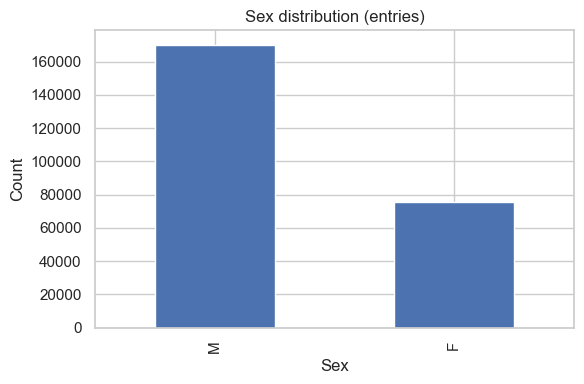

In [26]:
### Plot: Sex distribution
plt.figure(figsize=(6,4))
sex_counts.plot(kind="bar")
plt.title("Sex distribution (entries)")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("figures/Appendix/appendix_plot01_sex_distribution_entries.png", dpi=300, bbox_inches="tight")

plt.show()


In [28]:
### 8B) Age group distribution (requires age_imputed)
if "age_imputed" in df.columns:
    bins = [0, 15, 18, 21, 24, 27, 30, 35, 40, 50, 100]
    labels = ["<16", "16-18", "19-21", "22-24", "25-27", "28-30", "31-35", "36-40", "41-50", "51+"]


    df["age_group"] = pd.cut(df["age_imputed"], bins=bins, labels=labels, right=True)
    counts = df["age_group"].value_counts(dropna=False).sort_index()
    perc = (counts / counts.sum() * 100).round(2)
    pd.DataFrame({"count": counts, "percent": perc})
else:
    print("age_imputed not available.")


In [29]:
### 8C) Medal counts by country (team)
medalists = df[df["medal"].isin(["Gold","Silver","Bronze"])].copy()
country_medals = medalists.groupby("team").size().sort_values(ascending=False)

print("Top 10 countries by medalist entries:")
print(country_medals.head(10))


Top 10 countries by medalist entries:
team
United States     4807
Russia            3253
Germany           3234
United Kingdom    1683
France            1572
Italy             1476
Sweden            1231
Australia         1224
Canada            1124
China             1049
dtype: int64


In [30]:
### Countries with exactly 1 medalist entry
one_medal = country_medals[country_medals == 1]
print("Countries with exactly 1 medalist entry:", one_medal.shape[0])
one_medal.head(20)


Countries with exactly 1 medalist entry: 22


team
Andorra                   1
Bolivia                   1
Bosnia and Herzegovina    1
Barbados                  1
Dominica                  1
Eritrea                   1
Ivory Coast               1
Gabon                     1
Guyana                    1
Haiti                     1
Burkina Faso              1
Djibouti                  1
Monaco                    1
Mauritius                 1
Senegal                   1
Saint Lucia               1
Niger                     1
North Macedonia           1
Togo                      1
Sudan                     1
dtype: int64

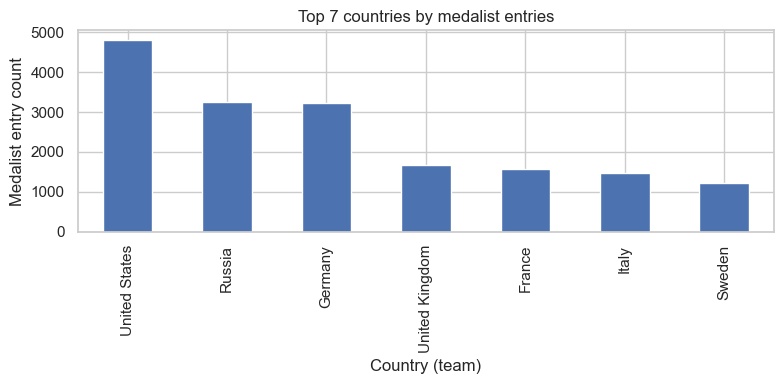

In [31]:
### Plot: Top 7 countries by medalist entries
top7 = country_medals.head(7)

plt.figure(figsize=(8,4))
top7.plot(kind="bar")
plt.title("Top 7 countries by medalist entries")
plt.xlabel("Country (team)")
plt.ylabel("Medalist entry count")
plt.tight_layout()
plt.savefig("figures/Appendix/appendix_plot02_top7_countries_by_medalist_entries.png", dpi=300, bbox_inches="tight")
plt.show()


In [32]:
### Top 10 countries by medal type (Gold/Silver/Bronze) + one summary table
gold = medalists[medalists["medal"]=="Gold"].groupby("team").size().sort_values(ascending=False).head(10)
silver = medalists[medalists["medal"]=="Silver"].groupby("team").size().sort_values(ascending=False).head(10)
bronze = medalists[medalists["medal"]=="Bronze"].groupby("team").size().sort_values(ascending=False).head(10)

pd.DataFrame({"Gold": gold, "Silver": silver, "Bronze": bronze}).fillna(0).astype(int)


,Gold,Silver,Bronze
team,,,
Australia,0,406,488
Canada,364,365,395
China,399,354,0
France,479,508,585
Germany,1114,1043,1077
Hungary,372,0,360
Italy,509,484,483
Russia,1265,1023,965
Sweden,369,427,435


# Research Question 1

## How do medal outcomes vary by age group and sex across sports, and which sports show the largest changes in gender parity and peak-age patterns across decades?

This research question examines how medal outcomes and participation patterns vary across demographic groups and over time. It focuses on whether age group and sex are associated with different medal patterns, and whether Olympic participation became more gender-balanced across decades.

This question matters because the Olympic Games have changed substantially over time. Understanding how medal outcomes vary by age and sex, and how gender parity evolves across decades, helps reveal broader patterns in athlete participation and performance.

We divide this research question into three focused subquestions so that each one addresses a specific part of the main question in detail:

- **RQ1(a):** How do medal outcomes vary by **age group** and **sex**?
- **RQ1(b):** Which decades show the largest changes in **gender parity** (**male vs female shares**)?
- **RQ1(c):** How do **peak-age patterns** change across decades (**median and IQR of medalist ages**)?

## RQ1(a): How do medal outcomes vary by age group and sex?

### Short overview
This subsection examines whether medal-winning entries are distributed differently across **age groups** and **sex**. It focuses only on medal-winning rows so that the analysis directly describes the composition of medal outcomes.

### Why this question matters
Age and sex are two important athlete characteristics. Looking at medal outcomes by age group and sex helps us understand whether certain age ranges are more strongly associated with medal success, and whether the balance between male and female medalist entries changes across age groups.

### Subquestion
**RQ1(a):** How do medal outcomes vary by **age group** and **sex**?

### Data preparation / variables used
For this subsection, we use:

- **`df_clean`**: working copy of the main dataset
- **`age_group`**: ordered age categories created from the athlete age variable
- **`sex`**: male (**M**) and female (**F**)
- **`medal`**: restricted to **Gold**, **Silver**, and **Bronze**
- **`medalists`**: a subset containing only medal-winning athlete-event rows

The next few cells prepare these variables before the plots are created.

### RQ1(a)-1) Create a working copy and decade variable

In [33]:
# 1. create a working copy of the dataset,
# 2. create a decade variable for trend analysis,

df_clean = df.copy()

# Create decade column for decade-level analysis
df_clean["decade"] = (df_clean["year"] // 10) * 10

### RQ1(a)-2) Create age groups

In [34]:
# RQ1(a)-2) Create ordered age-group categories
# ---------------------------------------------
# This cell detects the most appropriate age column and then creates
# ordered age-group categories used throughout RQ1 and RQ3.

if "age_col" not in globals():
    if "age_imputed" in df_clean.columns:
        age_col = "age_imputed"
    elif "age" in df_clean.columns:
        age_col = "age"
    else:
        age_col = None

print("Using age column:", age_col)

age_order = ["<16", "16-18", "19-21", "22-24", "25-27", "28-30", "31-35", "36-40", "41-50", "51+"]

if age_col is None:
    print("No valid age column available, so age groups could not be created.")
else:
    # Recreate age_group from scratch so the labels always match the bins
    if "age_group" in df_clean.columns:
        df_clean = df_clean.drop(columns=["age_group"])

    bins = [0, 15, 18, 21, 24, 27, 30, 35, 40, 50, 100]

    df_clean["age_group"] = pd.cut(
        df_clean[age_col],
        bins=bins,
        labels=age_order,
        right=True
    )

    df_clean["age_group"] = pd.Categorical(
        df_clean["age_group"],
        categories=age_order,
        ordered=True
    )

print(df_clean["age_group"].value_counts(dropna=False).sort_index())


Using age column: age_imputed
age_group
<16       2757
16-18    15509
19-21    41591
22-24    58133
25-27    50724
28-30    34848
31-35    27096
36-40     8960
41-50     5163
51+       1329
Name: count, dtype: int64


### RQ1(a)-3) Create the medalist-only subset

In [35]:
# Create a medalist-only subset
# For some parts of RQ1, we only want to study athletes who actually won medals.
# This step keeps rows where the medal value is Gold, Silver, or Bronze,
# and removes non-medal athlete-event rows from this subset.

medalists = df_clean[df_clean["medal"].isin(["Gold", "Silver", "Bronze"])].copy()

# Display the size of the medalist-only dataset
# This helps confirm how many athlete-event rows remain for medal-focused analysis.
print("Medalist-only dataset shape (rows, columns):", medalists.shape)

Medalist-only dataset shape (rows, columns): (34644, 15)


### RQ1(a) Plot 1: Medalist sex composition by age group

#### What this plot shows
This plot shows the percentage of medal-winning athlete-event rows that are **Female (F)** and **Male (M)** within each **age group**. Each stacked bar adds up to **100%**.

#### Why this plot is used
We use a **100% stacked bar chart** instead of raw counts because some age groups contain many more medalists than others. A count-based chart can make smaller groups harder to compare, while percentages allow a fair comparison of the **sex composition within each age group**.

The y-axis represents the **percent of medalist entries** in each age group.

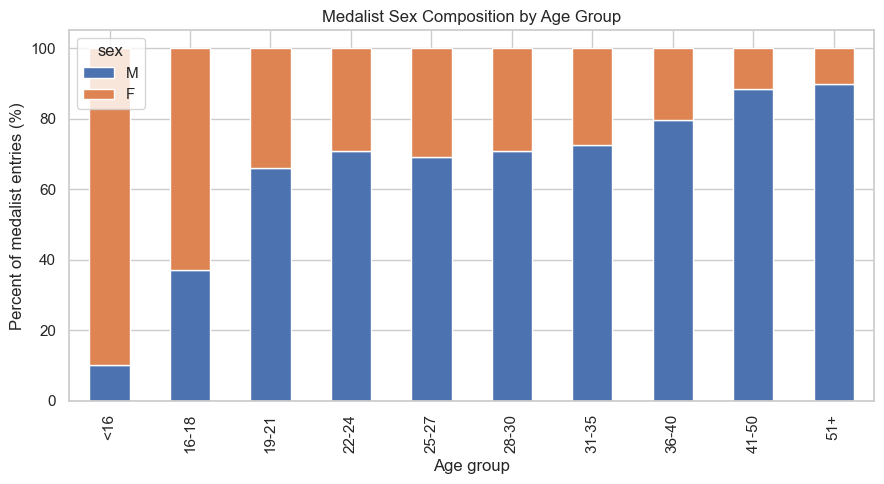

In [38]:
# RQ1(a)-Plot 1) Medalist sex composition by age group
# This plot shows the percentage of male and female medalist entries
# within each age group. Each bar sums to 100%, which makes it easier
# to compare sex composition across age groups of different sizes.

tab = (
    medalists.groupby(["age_group", "sex"])
    .size()
    .unstack(fill_value=0)
)

# Ensure both sex columns exist
# This prevents errors if one sex category is missing in any grouped result.
for s in ["M", "F"]:
    if s not in tab.columns:
        tab[s] = 0

# Keep age groups in the intended plotting order
tab = tab[["M", "F"]].reindex(age_order)

# Convert counts to percentages within each age group
# This makes each stacked bar total 100%.
prop = tab.div(tab.sum(axis=1), axis=0) * 100

# Create the 100% stacked bar chart
ax = prop.plot(kind="bar", stacked=True, figsize=(9, 5))

# Add plot labels and title
ax.set_title("Medalist Sex Composition by Age Group")
ax.set_xlabel("Age group")
ax.set_ylabel("Percent of medalist entries (%)")

plt.tight_layout()
plt.savefig("figures/RQ1/rq1_plot01_medalist_share_by_age_group_sex.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretation

Each bar represents one age group, and the bar is split into the percentage of medalist entries that are **Male (M)** and **Female (F)** within that group.

This makes it easier to compare the **sex composition of medalists across age groups**, even when some age groups contain many more medalists than others.

From the plot, the youngest age groups appear much more female-dominated, while many older age groups are more male-dominated. This suggests that the sex balance of medalists changes noticeably across age groups.

#### Limitations
- This plot includes **medalist entries only**, not all athlete-event rows.
- In team sports, one medal can appear multiple times because several athletes receive that medal, which can increase the number of medalist entries.

-----------------------------------------------

### RQ1(a) Plot 2: Medal type composition by age group

#### What this plot shows
This plot shows the percentage breakdown of **Gold**, **Silver**, and **Bronze** medal outcomes within each **age group**. Each stacked bar adds up to **100%**.

#### Why this plot is used
We use percentages instead of raw medal counts because the total number of medal-winning entries can differ a lot across age groups. A percentage-based plot makes it easier to compare whether some age groups tend to have a higher share of **Gold medals** or a lower share of **Bronze medals** relative to other age groups.

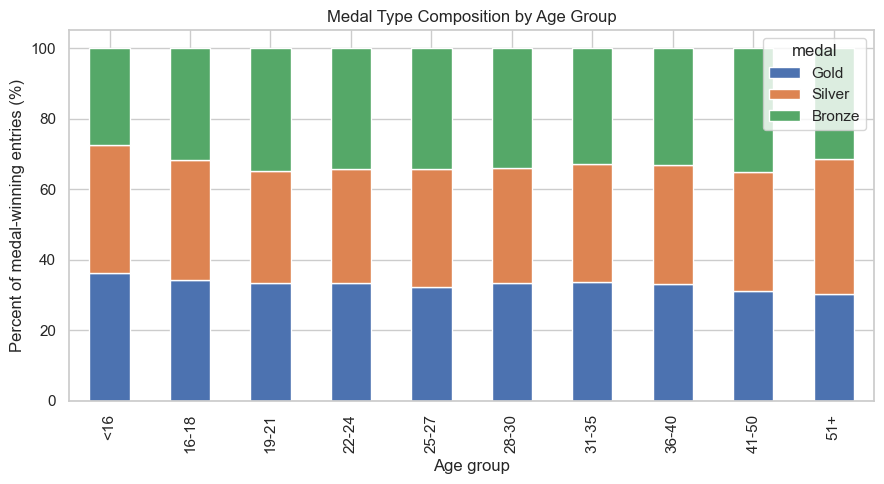

In [39]:
# RQ1(a)-Plot 2) Medal type composition by age group

# This plot shows how Gold, Silver, and Bronze medals are distributed
# within each age group. Each bar totals 100%, so the focus is on
# medal composition rather than total medal counts.

medal_tab = (
    medalists.groupby(["age_group", "medal"])
    .size()
    .unstack(fill_value=0)
)

# Ensure all medal categories exist
# This prevents errors if one medal type is missing in a grouped result.
for m in ["Gold", "Silver", "Bronze"]:
    if m not in medal_tab.columns:
        medal_tab[m] = 0

# Keep a consistent medal order and age-group order
medal_tab = medal_tab[["Gold", "Silver", "Bronze"]].reindex(age_order)

# Convert counts to percentages within each age group
# This makes each stacked bar sum to 100%.
medal_share = medal_tab.div(medal_tab.sum(axis=1), axis=0) * 100

# Create the stacked percentage bar chart
ax = medal_share.plot(kind="bar", stacked=True, figsize=(9, 5))

# Add plot labels and title
ax.set_title("Medal Type Composition by Age Group")
ax.set_xlabel("Age group")
ax.set_ylabel("Percent of medal-winning entries (%)")

plt.tight_layout()
plt.savefig("figures/RQ1/rq1_plot02_medal_type_share_by_age_group.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretation

Each bar represents one age group, and each bar sums to **100%**. The colors show how medal-winning entries in that age group are divided among **Gold**,**Silver**, and **Bronze** medals.

This plot helps us compare the **composition of medal types** across age groups rather than the total number of medals. In other words, it shows whether some age groups have a relatively larger share of **Gold medals** or a relatively smaller share of **Bronze medals**.

From the figure, the medal-type shares appear fairly similar across most age groups. This suggests that age group may matter more for **how many medalists appear** than for the **type of medal won** among medalists.

#### Limitations
- The plot does **not** show total medal counts, only the percentage breakdown within each age group.
- A small age group can still sum to 100%, even if it contains relatively few medalist entries.
- This figure is descriptive only and does not imply that age directly causes a particular medal outcome.

-------------------------------------------------------------

### Short subsection conclusion for RQ1(a)

Overall, the results suggest that medal outcomes vary across age groups in terms of **sex composition**, while the **Gold / Silver / Bronze composition** remains relatively stable across ages. This means age group appears more strongly related to **who the medalists are** than to **which medal type they win**.

## RQ1(b): Which decades show the largest changes in gender parity?

### Short overview
This subsection studies how the balance between male and female athlete-event entries changes across decades. It focuses on participation shares over time rather than medal outcomes, so that long-term gender representation trends can be identified clearly.

### Why this question matters
Gender parity is an important part of Olympic history. Examining how female and male participation shares change across decades helps show whether the Games became more inclusive over time and highlights the periods where the largest changes occurred.

### Subquestion
**RQ1(b):** Which decades show the largest changes in **gender parity** (**male vs female shares**)?

### Data preparation / variables used
For this subsection, we use:

- **`decade`**: created from the Olympic year variable
- **`sex`**: male (**M**) and female (**F**)
- grouped counts of athlete-event entries within each **decade × sex** combination
- **female share** and **male share**, calculated within each decade

The next cells use these variables to show both the overall long-run trend and the decades with the largest changes.

### RQ1(b) Plot 1: Gender parity over decades

#### What this plot shows
This plot shows how the share of **Female (F)** and **Male (M)** athlete-event entries changes across decades. The values are calculated **within each decade**, so the two lines represent long-term participation trends over time.

#### Why this plot is used
A value of **0.50** represents perfect gender parity, meaning equal female and male representation. As the female share moves closer to **0.50**, the Olympic entries become more gender-balanced.

We use **decades** instead of individual years because grouping by decade smooths short-term fluctuations and makes the long-run trend easier to interpret.

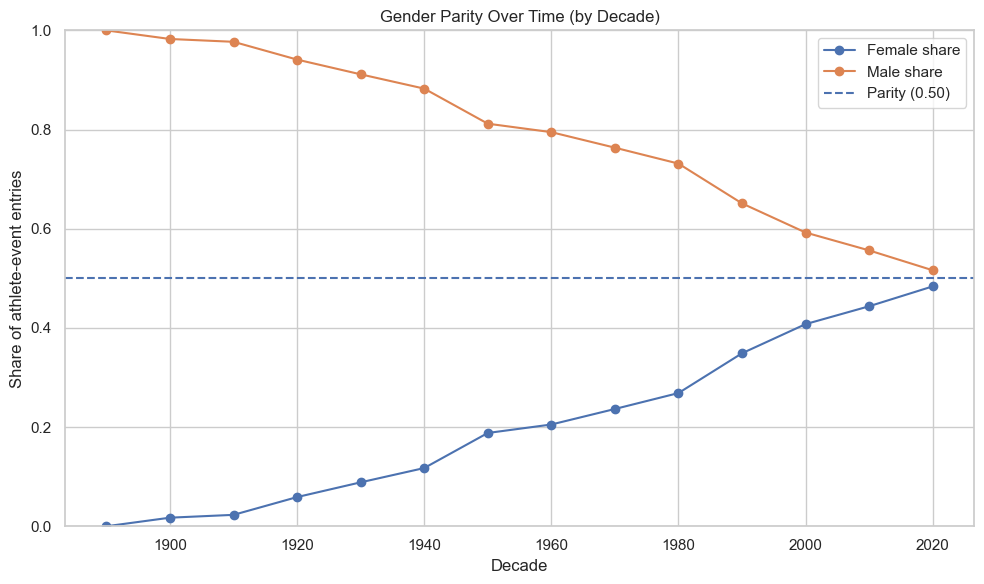

In [40]:
# RQ1(b)-Plot 1) Gender parity over decades
# This plot tracks how the female and male shares of athlete-event entries
# change over time. Shares are calculated within each decade so that
# long-term trends in gender balance are easier to see.

tmp = df_clean.dropna(subset=["decade", "sex"]).copy()

# Count athlete-event entries by decade and sex
parity = (
    tmp.groupby(["decade", "sex"])
    .size()
    .unstack(fill_value=0)
)

# Ensure both sex categories exist
# This prevents errors if one category is missing in a grouped result.
for s in ["M", "F"]:
    if s not in parity.columns:
        parity[s] = 0

# Convert counts to shares within each decade
parity["female_share"] = parity["F"] / (parity["F"] + parity["M"])
parity["male_share"] = parity["M"] / (parity["F"] + parity["M"])

# Create the line plot
plt.figure(figsize=(10, 6))
plt.plot(parity.index, parity["female_share"], marker="o", label="Female share")
plt.plot(parity.index, parity["male_share"], marker="o", label="Male share")
plt.axhline(0.5, linestyle="--", label="Parity (0.50)")

# Add plot labels and title
plt.title("Gender Parity Over Time (by Decade)")
plt.xlabel("Decade")
plt.ylabel("Share of athlete-event entries")
plt.ylim(0, 1)
plt.legend()

plt.tight_layout()
plt.savefig("figures/RQ1/rq1_plot03_gender_parity_by_decade.png", dpi=300, bbox_inches="tight")
plt.show()

### Interpretation

Each point represents one decade. The **female share** line shows the proportion of athlete-event entries that are female in that decade, while the **male share** line shows the corresponding male proportion. The dashed line at **0.50** marks perfect gender parity.

The plot shows a clear long-run increase in female participation over time, while the male share declines toward parity. This indicates that the Olympic Games became progressively more gender-balanced across decades.

If some decades show slower improvement or temporary plateaus, this may reflect historical events, changes in Olympic event inclusion, or differences in dataset coverage.

#### Limitations
- This plot measures **participation entries**, not medal outcomes.
- The trend can be influenced by dataset composition, such as changes in included sports, years, or event types.
- The figure is descriptive and does not explain the causes of changing gender parity.

------------------------------

### RQ1(b) Plot 2: Largest decade-to-decade changes in female participation share

#### What this plot shows
This plot shows how much the **female participation share** changes from one decade to the next. We use the **absolute change** \(|\Delta|\) so that the plot focuses on the **size of the shift**, regardless of whether the change was upward or downward.

#### Why this plot is used
Higher points indicate decades where gender representation changed the most. These peaks highlight the periods that contributed most strongly to changes in Olympic gender parity over time.

We focus only on **female share** because the change in male share is mathematically redundant:
\[
\text{male share} = 1 - \text{female share}
\]
so both series have the same absolute change.

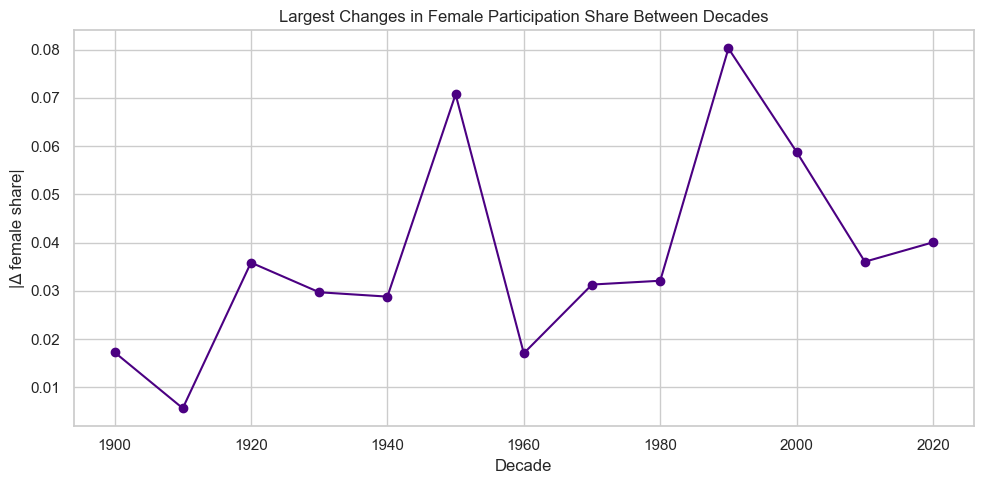

Top 5 decades with the largest absolute changes in female share:


decade
1990    0.080231
1950    0.070720
2000    0.058777
2020    0.040069
2010    0.036048
Name: female_share, dtype: float64

In [41]:
# RQ1(b)-Plot 2) Largest decade-to-decade changes in female participation share
# -----------------------------------------------------------------------------
# This plot shows how much the female participation share changes
# between consecutive decades. We use the absolute change so that
# we focus on the size of the shift, not the direction.

# Compute the absolute change in female share between consecutive decades
parity_change_f = parity["female_share"].diff().abs()

# Create the line plot
plt.figure(figsize=(10, 5))
plt.plot(
    parity_change_f.index,
    parity_change_f.values,
    marker="o",
    color="Indigo"   # changed from blue to dark orange for better contrast
)

# Add plot labels and title
plt.title("Largest Changes in Female Participation Share Between Decades")
plt.xlabel("Decade")
plt.ylabel("|Δ female share|")

plt.tight_layout()
plt.savefig("figures/RQ1/rq1_plot04_largest_decade_to_decade_change_in_female_share.png", dpi=300, bbox_inches="tight")

plt.show()

# Display the top 5 decades with the largest changes
top5_f = parity_change_f.sort_values(ascending=False).head(5)

print("Top 5 decades with the largest absolute changes in female share:")
display(top5_f)

### Interpretation

Each point measures how much the **female share of athlete-event entries** changed compared with the previous decade. Because the values are shown in absolute terms, the plot highlights the **largest shifts in participation balance**, regardless of direction.

The highest peaks identify the decades in which female representation changed most strongly. These can be interpreted as key transition periods in the long-run movement toward greater gender parity in Olympic participation.

If the largest shifts cluster in certain historical periods, that may reflect broader structural changes such as policy changes, event expansion, or increased inclusion of women’s competitions.

#### Limitations
- The measured changes may depend on which Olympic editions are included in each decade of the dataset.
- This plot tracks **participation share**, not medal share.
- Male-share changes are not shown because they are identical in magnitude to female-share changes.

-------------------------------------

### Short subsection conclusion for RQ1(b)

Overall, the results show a strong long-run movement toward gender parity in Olympic participation. Female representation rises steadily across decades, and the decade-to-decade change plot highlights the key periods where the largest shifts occurred. Together, these figures show both the **direction** and the **timing** of progress toward gender balance.

### RQ1(c) Plot 1: Peak-age patterns across decades using all sports together

#### Short overview
This subsection examines how the **typical medal-winning age** changes across decades for **female** and **male** medalists when all sports are combined into one overall Olympic view.

#### Why this question matters
Peak-performance age is an important part of athlete success. Looking at median age and the spread of ages across decades helps show whether medal-winning athletes are becoming younger, older, or more varied over time.

#### Subquestion
**RQ1(c):** How do **peak-age patterns** change across decades (**median and IQR of medalist ages**)?

#### Key terms
- **Medalist:** an athlete-event row where `medal` is **Gold**, **Silver**, or **Bronze**
- **Decade:** a grouped time period based on the Olympic year, used to smooth long-term trends
- **Median age:** the middle age after sorting all medalist ages in a decade; used here as a measure of the **typical** medal-winning age
- **IQR (Interquartile Range):** the range from the **25th percentile (Q1)** to the **75th percentile (Q3)**; this represents the middle 50% of medalist ages

#### What this plot shows
- the **median medalist age** by decade for females and males
- the **IQR band** by decade for females and males

#### Why this plot is used
We combine medalists from **all sports** to create one clear overall picture of Olympic peak-age patterns. This avoids focusing on only one sport and provides a clean summary figure for the report.

Using age column: age_imputed


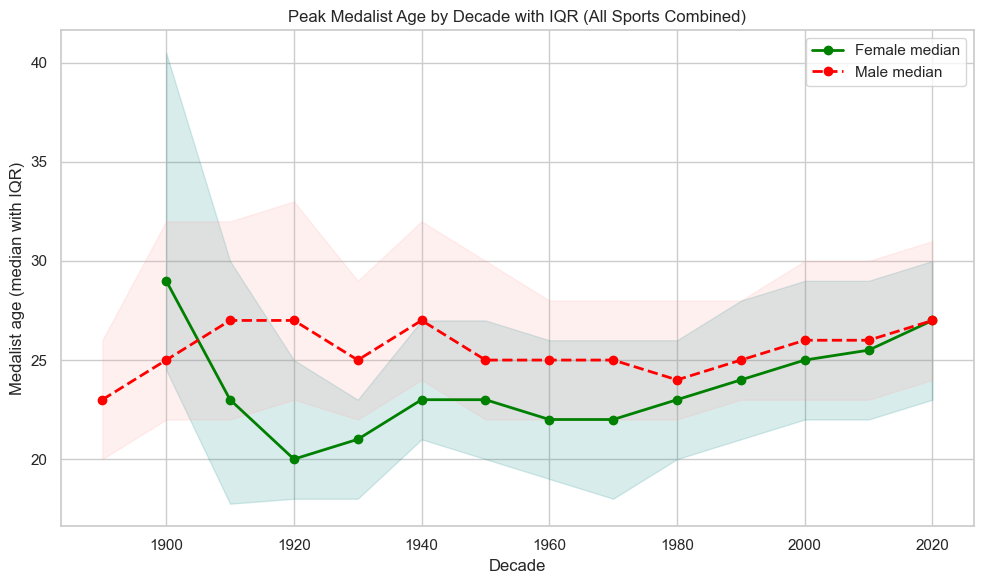

In [42]:
# RQ1(c)-Plot 1) Peak-age patterns across decades using all sports together
# ------------------------------------------------------------------------
# This plot shows how the typical medalist age changes over time for
# female and male medalists. We use the median age as the central trend
# and the IQR (Q1 to Q3) as the spread of the middle 50% of ages.
# Make sure age_col exists
if "age_col" not in globals():
    if "age" in df_clean.columns:
        age_col = "age"
    else:
        age_col = None

print("Using age column:", age_col)

# Check that an age column is available
if age_col is None:
    print("No age column available for peak-age analysis.")
else:
    # Keep only medalist rows with valid ages
    medalists_age = medalists.dropna(subset=[age_col]).copy()

    # Helper function:
    # For one sex, compute the median age, lower quartile (Q1),
    # upper quartile (Q3), and sample size by decade.
    def decade_quantiles(df, sex_value):
        sub = df[df["sex"] == sex_value]
        grouped = sub.groupby("decade")[age_col]

        out = pd.DataFrame({
            "median": grouped.median(),
            "q25": grouped.quantile(0.25),
            "q75": grouped.quantile(0.75),
            "n": grouped.size()
        }).reset_index().sort_values("decade")

        return out

    # Compute decade summaries separately for females and males
    F = decade_quantiles(medalists_age, "F")
    M = decade_quantiles(medalists_age, "M")

    # Create the plot
    plt.figure(figsize=(10, 6))

    # Female median line and IQR band
    if len(F) > 0:
        plt.fill_between(
            F["decade"], F["q25"], F["q75"],
            color="teal", alpha=0.15
        )
        plt.plot(
            F["decade"], F["median"],
            marker="o", color="Green", linewidth=2,
            label="Female median"
        )

    # Male median line and IQR band
    if len(M) > 0:
        plt.fill_between(
            M["decade"], M["q25"], M["q75"],
            color="#FF9D9C", alpha=0.15
        )
        plt.plot(
            M["decade"], M["median"],
            marker="o", linestyle="--", color="Red", linewidth=2,
            label="Male median"
        )

    # Add labels and title
    plt.title("Peak Medalist Age by Decade with IQR (All Sports Combined)")
    plt.xlabel("Decade")
    plt.ylabel("Medalist age (median with IQR)")
    plt.legend()

    plt.tight_layout()
    plt.savefig("figures/RQ1/rq1_plot05_peak_medalist_age_by_decade_iqr.png", dpi=300, bbox_inches="tight")
    plt.show()

### Interpretation

The lines show the **median medalist age** for females and males in each decade, while the shaded bands show the **IQR**, or middle 50% of medalist ages. Together, these show both the typical age and the spread of medal-winning ages over time.

If the median age rises across decades, it suggests that the typical medal-winning age is increasing. If the IQR becomes wider, it suggests that a broader range of ages is represented among medalists in that period.

Because all sports are combined, this plot gives one overall Olympic age pattern rather than a sport-specific one. It is useful for understanding long-term shifts in peak-age patterns at the broadest level.

#### Limitations
- Combining all sports hides sport-specific age patterns, which may differ a lot across events.
- Team events can create multiple medalist rows for a single medal outcome.
- If ages were imputed earlier in the workflow, that may slightly smooth the age pattern.
- Early female decades may be less stable if the sample size is small.

### RQ1-5 Export summary tables used in RQ1

In [43]:
# RQ1(c)-Interpretation support) Compare overall median medalist age by sex
# ------------------------------------------------------------------------
# This summary compares the pooled median medalist age for female and male
# medalists across all decades combined.

overall_f_med = medalists_age[medalists_age["sex"] == "F"][age_col].median()
overall_m_med = medalists_age[medalists_age["sex"] == "M"][age_col].median()

print("Overall median medalist age (Female):", round(float(overall_f_med), 2))
print("Overall median medalist age (Male):  ", round(float(overall_m_med), 2))

Overall median medalist age (Female): 25.0
Overall median medalist age (Male):   26.0


# Research Question 2

## To what extent is the number of athletes a country sends associated with its total medal count, and how does this relationship shape dominance in a given Olympic year?

This research question focuses on **country participation size, medal counts, efficiency, and Olympic dominance**.

We divide this research question into three focused subquestions so that each one answers a specific part of the main question in detail:

- **RQ2(a):** Is there a positive relationship between the number of athletes a country sends and the number of medals it wins?
- **RQ2(b):** Which countries are the most efficient at converting participation into medals?
- **RQ2(c):** Which countries dominate the Olympic Games in a given year, and is this dominance primarily driven by delegation size or efficiency?

> **Important data note:** this dataset does not include a unique athlete identifier. Because of that, this section uses **country-year participation size** as a proxy for delegation size, measured by the number of athlete-event rows for each country in a given Olympic year.


## RQ2(a): Is there a positive relationship between the number of athletes a country sends and the number of medals it wins?

### Short overview
This subsection examines whether countries with larger Olympic participation tend to win more medals. Because the dataset does not contain a unique athlete identifier, we study this relationship at the **country-year** level using **athlete-event rows** as a proxy for delegation size.

### Why this question matters
A positive relationship between participation size and medal count would suggest that larger delegations have a structural advantage in Olympic success. At the same time, the strength and shape of that relationship matter, because medal outcomes may also depend on other factors such as sport breadth and historical changes across years.

### Subquestion
**RQ2(a):** Is there a positive relationship between the number of athletes a country sends and the number of medals it wins?

### Data preparation / variables used
For this subsection, we use:

- **`team_clean`**: cleaned country/team label used for country-like grouping
- **`year`**: Olympic year
- **`participation_size`**: number of athlete-event rows for a country in a given year, used as a proxy for delegation size
- **`event_medals`**: number of medal-winning country-event outcomes using the **event-medal method**
- **`num_sports`**: number of distinct sports entered by a country in a given year
- **`log_participation_size`** and **`log_event_medals`**: log-transformed variables used to reduce skew and improve interpretability

Because team events can create multiple medal-winning rows for a single medal, we use the **event-medal method** rather than counting every medalist row directly. This gives a fairer country-level medal count.


### RQ2(a)-1: Build the country-year analysis table


In [44]:

# RQ2(a)-1) Build a country-year table for participation size and event medals
# This step creates the working dataset used throughout RQ2(a).
# We clean country/team labels, remove obvious non-country artifacts,
# count participation size by country-year, and count event medals
# using the event-medal method.

df_sq1 = df_clean.copy()

# Clean team names so country-like grouping is easier to interpret
df_sq1["team_clean"] = (
    df_sq1["team"].astype(str)
    .str.replace(r"-\d+$", "", regex=True)
    .str.strip()
)

# Remove obvious non-country artifacts that should not be treated as countries
bad_patterns = ["Boat", "Club", "Vesper", "Magda", "Union des", "Athletes"]
mask_bad = df_sq1["team_clean"].str.contains("|".join(bad_patterns), case=False, na=False)
df_sq1 = df_sq1[~mask_bad].copy()

# Keep medal-winning rows only for medal counting
medalists_sq1 = df_sq1[df_sq1["medal"].isin(["Gold", "Silver", "Bronze"])].copy()

# Count each medal event once per country-year to avoid overcounting team events
event_medals_sq1 = medalists_sq1.drop_duplicates(
    ["year", "event", "team_clean", "medal"]
).copy()

# Participation size is measured using athlete-event rows for each country-year
entries_cy = (
    df_sq1.groupby(["year", "team_clean"])
    .size()
    .rename("participation_size")
)

# Event-medal count for each country-year
event_medals_cy = (
    event_medals_sq1.groupby(["year", "team_clean"])
    .size()
    .rename("event_medals")
)

# Build the final country-year analysis table
sq1 = pd.concat([entries_cy, event_medals_cy], axis=1).fillna(0).reset_index()
sq1["event_medals"] = sq1["event_medals"].astype(int)

print("Country-year rows:", sq1.shape)
display(sq1.head())


Country-year rows: (3376, 4)


,year,team_clean,participation_size,event_medals
0,1896,Australia,4,2
1,1896,Austria,8,5
2,1896,Denmark,15,6
3,1896,France,19,11
4,1896,Germany,64,13


### RQ2(a)-2: Quick summary statistics


In [45]:

# RQ2(a)-2) Summarize the main variables used in the analysis
# These summaries help us understand the scale, spread, and basic
# correlation of participation size and event medals before plotting.

print("Participation size summary:")
print(sq1["participation_size"].describe())

print("\nEvent medal summary:")
print(sq1["event_medals"].describe())

print("\nCorrelation matrix:")
print(sq1[["participation_size", "event_medals"]].corr())


Participation size summary:
count    3376.000000
mean       72.899882
std       119.154277
min         1.000000
25%         6.000000
50%        21.000000
75%        82.000000
max      1058.000000
Name: participation_size, dtype: float64

Event medal summary:
count    3376.000000
mean        5.996445
std        16.060201
min         0.000000
25%         0.000000
50%         0.000000
75%         5.000000
max       217.000000
Name: event_medals, dtype: float64

Correlation matrix:
                    participation_size  event_medals
participation_size            1.000000      0.836578
event_medals                  0.836578      1.000000


## RQ2(a) Plot 1: Participation size vs event medals by country-year

### What this plot shows
This scatterplot shows the relationship between **country-year participation size** and **country-year event medals**. Each point represents one country in one Olympic year.

### Why this plot is used
This is the most direct descriptive plot for checking whether countries with larger delegations tend to win more medals. It helps us identify the overall direction of association, the spread of the data, and whether the relationship already appears linear.


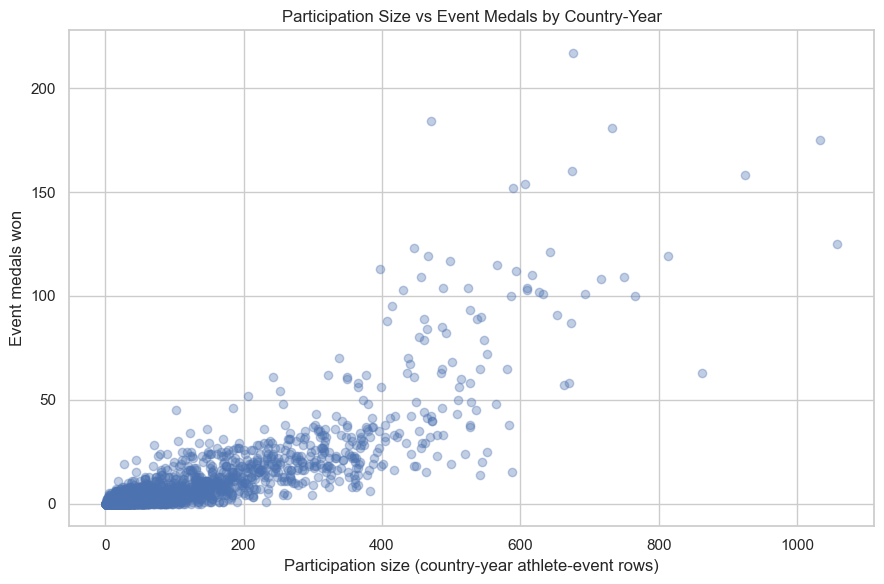

In [48]:

# RQ2(a)-Plot 1) Scatterplot of participation size vs event medals
# ----------------------------------------------------------------
# Each point is one country-year observation. This plot is used to
# visually check whether larger country-year participation tends to
# be associated with higher event-medal counts.

plt.figure(figsize=(9, 6))
plt.scatter(
    sq1["participation_size"],
    sq1["event_medals"],
    alpha=0.35
)

plt.title("Participation Size vs Event Medals by Country-Year")
plt.xlabel("Participation size (country-year athlete-event rows)")
plt.ylabel("Event medals won")
plt.tight_layout()
plt.savefig("figures/RQ2/rq2_plot01_participation_size_vs_event_medals.png", dpi=300, bbox_inches="tight")

plt.show()


### Interpretation

This scatterplot shows a clear **positive relationship** between country-year participation size and event medals won. In general, country-years with larger delegations tend to win more medals.

However, the points are **not tightly clustered** around a single straight line. The spread becomes noticeably **wider for larger delegations**, which suggests that countries sending many athlete-event entries can still differ a lot in medal outcomes. In other words, larger participation is associated with greater medal success on average, but it does not guarantee the same level of efficiency for every country-year.

The plot also suggests **heteroscedasticity**, because the vertical spread in medals increases as participation size increases. A few country-year observations with very large delegations and very high medal totals stand out as possible **high-leverage points** or **outliers**.

Overall, this figure supports the idea that participation size and medal count are positively associated, but the relationship appears somewhat **non-linear** and more variable at higher participation levels. This is why later plots and regressions consider transformations and model fit more carefully.

#### Limitations
- This plot uses **athlete-event rows** rather than exact unique athletes.
- The relationship may be **non-linear**, especially because both participation size and medal counts are highly skewed.
- Larger delegations may also create more variability, which a simple visual summary cannot fully explain.

### RQ2(a)-3: Least-squares regression helpers


In [49]:

# RQ2(a)-3) Define helper functions for simple least-squares regression
# --------------------------------------------------------------------
# These functions are used to compute the correlation, slope, intercept,
# predictions, and mean squared error for the simple regression model.

def standard_units(x):
    return (x - np.mean(x)) / np.std(x)

def correlation(x, y):
    return np.mean(standard_units(x) * standard_units(y))

def slope(x, y):
    return correlation(x, y) * np.std(y) / np.std(x)

def intercept(x, y):
    return np.mean(y) - slope(x, y) * np.mean(x)

def fit_least_squares(x, y):
    theta_0 = intercept(x, y)
    theta_1 = slope(x, y)
    return theta_0, theta_1

def predict(x, theta_0, theta_1):
    return theta_0 + theta_1 * x

def compute_mse(y, yhat):
    return np.mean((y - yhat) ** 2)


### RQ2(a)-4: Fit the simple linear regression model

We first fit a simple least-squares regression of the form

\[
	ext{event\_medals} = 	heta_0 + 	heta_1(	ext{participation\_size})
\]

A positive slope would support the idea that countries with larger delegations tend to win more event medals.


In [50]:

# RQ2(a)-4) Fit the simple least-squares regression model
# -------------------------------------------------------
# This model uses participation size alone to predict event medals.
# It is a useful starting point for checking whether the overall
# relationship is positive and roughly linear.

x_raw = sq1["participation_size"].to_numpy()
y_raw = sq1["event_medals"].to_numpy()

theta_0_raw, theta_1_raw = fit_least_squares(x_raw, y_raw)
yhat_raw = predict(x_raw, theta_0_raw, theta_1_raw)

print(f"x_mean : {np.mean(x_raw):.2f}, y_mean : {np.mean(y_raw):.2f}")
print(f"x_stdev: {np.std(x_raw):.2f}, y_stdev: {np.std(y_raw):.2f}")
print(f"r = Correlation(x, y): {correlation(x_raw, y_raw):.3f}")
print(f"theta_0: {theta_0_raw:.3f}, theta_1: {theta_1_raw:.3f}")
print(f"RMSE: {np.sqrt(compute_mse(y_raw, yhat_raw)):.3f}")


x_mean : 72.90, y_mean : 6.00
x_stdev: 119.14, y_stdev: 16.06
r = Correlation(x, y): 0.837
theta_0: -2.224, theta_1: 0.113
RMSE: 8.797


The results suggest a strong positive association between country-year participation size and event medals won. The correlation of $r = 0.837$ indicates that countries sending larger delegations generally win more medals. The fitted slope ($\theta_1 = 0.113$) implies that medal counts increase on average as participation size rises. However, the RMSE of $8.797$ suggests that a simple linear model still leaves substantial prediction error, so delegation size alone does not fully explain medal outcomes.


## RQ2(a) Plot 2: Participation size vs event medals with least-squares fit

### What this plot shows
This plot overlays the fitted least-squares line on top of the country-year scatterplot.

### Why this plot is used
The fitted line helps us see whether the average relationship between participation size and event medals is positive, and whether a straight-line model gives a reasonable first summary of the data.


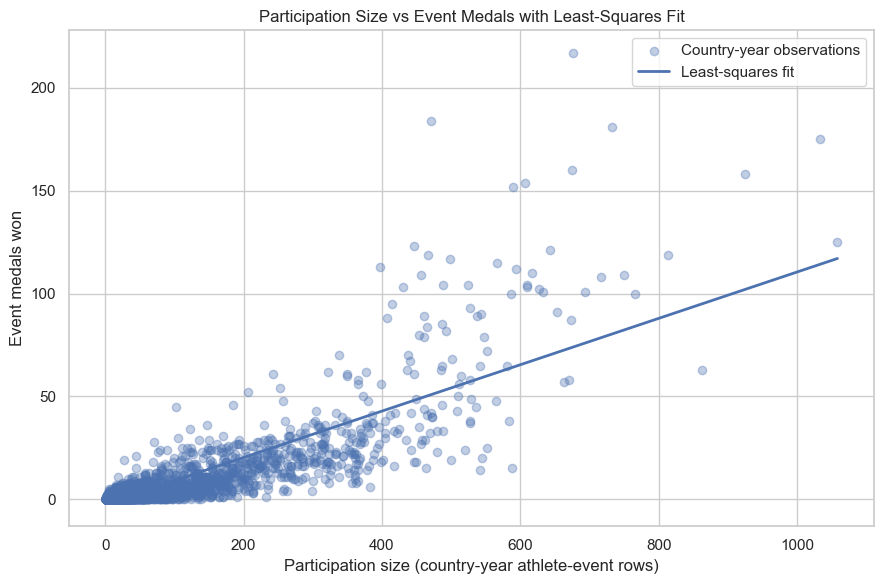

In [51]:

# RQ2(a)-Plot 2) Scatterplot with the simple least-squares fit
# ------------------------------------------------------------
# This plot combines the raw country-year observations with the
# fitted regression line from the simple linear model.

order_raw = np.argsort(x_raw)
x_raw_sorted = x_raw[order_raw]
yhat_raw_sorted = yhat_raw[order_raw]

plt.figure(figsize=(9, 6))
plt.scatter(x_raw, y_raw, alpha=0.35, label="Country-year observations")
plt.plot(x_raw_sorted, yhat_raw_sorted, linewidth=2, label="Least-squares fit")

plt.title("Participation Size vs Event Medals with Least-Squares Fit")
plt.xlabel("Participation size (country-year athlete-event rows)")
plt.ylabel("Event medals won")
plt.legend()
plt.tight_layout()
plt.savefig("figures/RQ2/rq2_plot02_participation_vs_event_medals_least_squares_fit.png", dpi=300, bbox_inches="tight")
plt.show()


### Interpretation

This scatterplot shows a clear positive relationship between country-year participation size and event medals won. In general, countries that send more athlete-event entries tend to win more medals.

The fitted least-squares line summarizes this overall upward trend, but the points are not tightly clustered around the line. Instead, the spread becomes wider as participation size increases, which suggests greater variability among larger delegations. This means that while larger participation is associated with more medals on average, countries with similar delegation sizes can still differ substantially in medal outcomes.

A few country-year observations with very large delegations and unusually high medal counts stand out as possible outliers or high-leverage points. Overall, the figure supports a strong positive association, but it also suggests that the relationship is not perfectly linear and becomes more variable at higher participation levels.

#### Limitations
- This plot uses **athlete-event rows** rather than exact unique athletes.
- The spread increases for larger delegations, so the variance is not constant.
- A few extreme observations may influence the fitted line.

### RQ2(a)-5: Log-transform the variables for a clearer linear pattern

The raw scatterplot is strongly right-skewed, and many country-year observations are densely packed near the lower-left corner. To improve visibility and check whether the relationship becomes more linear, we apply a **log(1 + x)** transformation to both participation size and event medals.


In [52]:
# RQ2(a)-5) Create log-transformed variables
# ------------------------------------------
# The log(1 + x) transformation reduces skew and spreads out the
# lower part of the data cloud, making the relationship easier to see.

import seaborn as sns

sns.set_theme(style="white", context="notebook")

sq1["log_participation_size"] = np.log1p(sq1["participation_size"])
sq1["log_event_medals"] = np.log1p(sq1["event_medals"])

x_log = sq1["log_participation_size"].to_numpy()
y_log = sq1["log_event_medals"].to_numpy()

theta_0_log, theta_1_log = fit_least_squares(x_log, y_log)
yhat_log = predict(x_log, theta_0_log, theta_1_log)

print(f"log-model correlation: {correlation(x_log, y_log):.3f}")
print(f"log-model slope: {theta_1_log:.3f}")
print(f"log-model intercept: {theta_0_log:.3f}")


log-model correlation: 0.832
log-model slope: 0.680
log-model intercept: -1.271


## RQ2(a) Plot 3: Log-transformed participation size vs log-transformed event medals

### What this plot shows
This plot shows the relationship between **log(1 + participation size)** and **log(1 + event medals)**, along with a least-squares fit line.

### Why this plot is used
The log transformation spreads out densely packed observations and helps reveal whether the relationship is closer to linear on the transformed scale. This makes it easier to judge whether participation size and medal count move together in a more stable way.


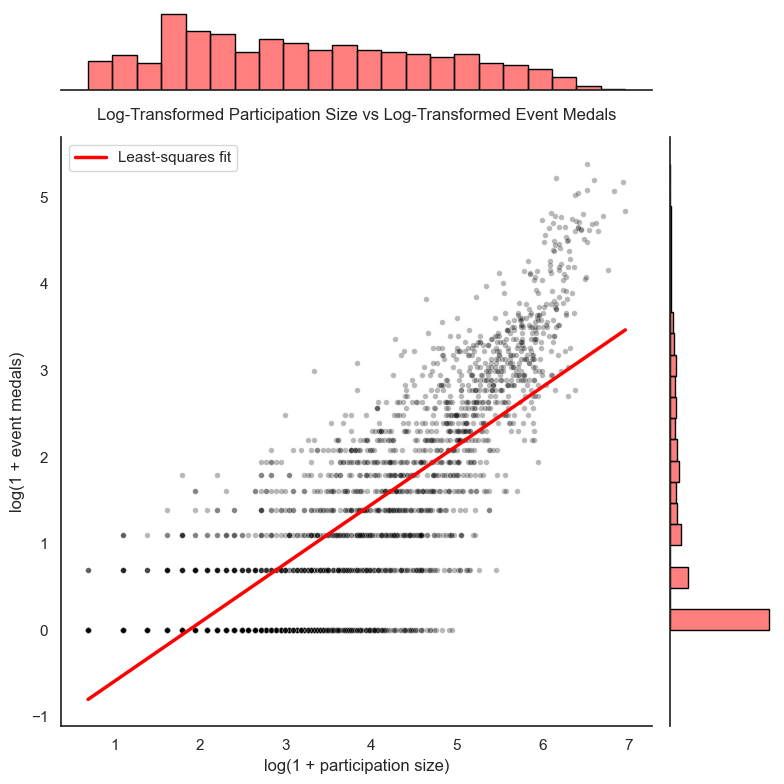

In [53]:

# RQ2(a)-Plot 3) Joint plot of the log-transformed relationship
# -------------------------------------------------------------
# This plot gives a clearer view of the country-year relationship
# after log transformation and includes the fitted least-squares line.

order_log = np.argsort(x_log)

g = sns.jointplot(
    x=x_log,
    y=y_log,
    kind="scatter",
    height=8,
    space=0,
    color="#000000",
    joint_kws={"s": 16, "alpha": 0.28},
    marginal_kws={
        "bins": 22,
        "fill": True,
        "alpha": 0.5,
        "color": "red",
        "edgecolor": "#000000"
    }
)

g.ax_joint.plot(
    x_log[order_log],
    yhat_log[order_log],
    color="red",
    linewidth=2.5,
    label="Least-squares fit"
)

g.ax_joint.set_xlabel("log(1 + participation size)")
g.ax_joint.set_ylabel("log(1 + event medals)")
g.ax_joint.set_title(
    "Log-Transformed Participation Size vs Log-Transformed Event Medals",
    pad=12
)
g.ax_joint.legend()

plt.tight_layout()
plt.savefig("figures/RQ2/rq2_plot03_log_transformed_participation_vs_event_medals.png", dpi=300, bbox_inches="tight")
plt.show()


### Interpretation

The log-transformed plot makes the relationship between participation size and event medals **much easier to see**. After applying `log(1 + x)` and `log(1 + y)`, the points are less compressed near zero, so small and medium-sized country-year observations become more visible.

Compared with the raw-scale scatterplot, the transformed point cloud appears **more evenly spread** and follows a **clearer positive linear trend**. The fitted line runs more closely through the center of the data, which suggests that the log transformation improves the suitability of a linear regression approach.

The transformation also reduces the extreme visual dominance of very large delegations and medal counts. As a result, the overall relationship looks more stable, with less severe skewness and a more interpretable pattern across the full range of country-year observations.

Overall, this figure suggests that a **log-transformed regression** provides a better representation of the relationship than the raw-scale model, especially because both participation size and medal counts are highly right-skewed.

#### Limitations
- Even after transformation, the relationship still shows noticeable variation around the fitted line.
- A log transformation improves visibility and linearity, but it does not guarantee that a one-predictor model fully explains medal outcomes.
- Because event medals are discrete counts, some horizontal banding remains visible even after transformation.


## RQ2(a) Plot 4: Residual plot for the log-transformed simple regression

### What this plot shows
This residual plot shows the difference between the observed and fitted values from the **log-transformed simple regression model**.

### Why this plot is used
Residuals help us check whether a straight-line model is a reasonable summary. If the residuals are randomly scattered around zero, the model is more appropriate. If there is visible curvature or a widening spread, the relationship may not be fully captured by a simple linear fit.


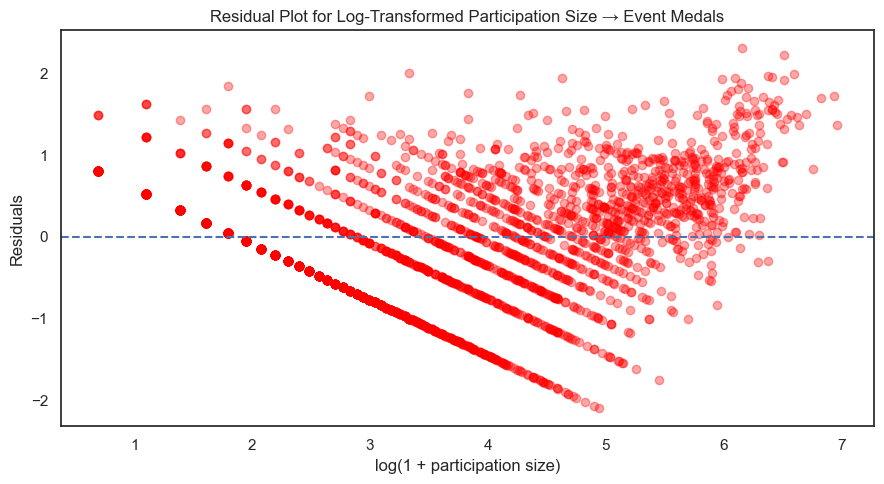

In [54]:

# RQ2(a)-Plot 4) Residual plot for the log-transformed simple regression
# ----------------------------------------------------------------------
# Residuals are calculated on the log-transformed scale. This helps us
# check whether the simple linear model leaves systematic patterns behind.

residuals_log = y_log - yhat_log

plt.figure(figsize=(9, 5))
plt.scatter(x_log, residuals_log, alpha=0.35, color="red")
plt.axhline(y=0, linestyle="--")

plt.title("Residual Plot for Log-Transformed Participation Size → Event Medals")
plt.xlabel("log(1 + participation size)")
plt.ylabel("Residuals")
plt.tight_layout()
plt.savefig("figures/Appendix/appendix_plot04_simple_regression_log_residuals.png", dpi=300, bbox_inches="tight")
plt.show()


### Interpretation

This residual plot shows that the log-transformed linear model is still only a **first approximation**, not a perfect fit. Although many residuals are centered around zero, the plot does **not** look like a completely random cloud.

There are still visible patterns in the residuals, including **banding**, **clustering**, and a changing spread across the x-axis. The diagonal bands occur because event medals are count-based and the log transformation does not remove their discrete structure. The spread also appears uneven for different participation levels, which suggests that the variance is still not fully constant.

This means the simple regression is useful as an **initial summary of the positive relationship** between participation size and medals, but it does not capture the data perfectly. In particular, countries with similar participation sizes can still have noticeably different medal outcomes, so participation size alone is not enough to explain all variation.

Overall, the residual plot suggests that the log-transformed model is **better than the raw-scale model**, but still limited. It is acceptable as a simple descriptive model for RQ2(a), though a richer model with additional predictors would likely explain medal outcomes more accurately.

#### Limitations
- Residual plots can reveal model problems, but they do not identify the exact cause.
- Country-year medal outcomes may depend on additional predictors beyond participation size alone.
- Because medals are discrete counts, some residual structure remains even after log transformation.

### RQ2(a)-6: Extend the analysis with multiple regression

The simple linear regression is useful as a first summary, but Olympic medal outcomes are likely influenced by more than delegation size alone. To account for this, we extend the analysis using a multiple regression model on the log-transformed response:

\[
\log(1+	ext{event\_medals}) =
eta_0 +
eta_1\log(1+	ext{participation\_size}) +
eta_2(	ext{num\_sports}) +
eta_3(	ext{year}) + 
arepsilon
\]

This model is a reasonable next step because it remains within ordinary least squares regression, while allowing the analysis to control for broader sport participation and long-run historical change.


In [55]:

# RQ2(a)-6) Build additional predictors and fit the multiple regression model
# ---------------------------------------------------------------------------
# We add the number of sports entered by each country-year and the Olympic year.
# The goal is to check whether participation size still matters after controlling
# for broader sport coverage and time.

import statsmodels.api as sm

# Count the number of distinct sports entered by each country-year
num_sports_cy = (
    df_sq1.groupby(["year", "team_clean"])["sports"]
    .nunique()
    .rename("num_sports")
    .reset_index()
)

# Merge num_sports into the country-year analysis table
sq1 = sq1.drop(columns=["num_sports"], errors="ignore").merge(
    num_sports_cy,
    on=["year", "team_clean"],
    how="left"
)
sq1["num_sports"] = sq1["num_sports"].fillna(0).astype(int)

# Fit the multiple regression model
y_multi = sq1["log_event_medals"]
X_multi = sq1[["log_participation_size", "num_sports", "year"]]
X_multi = sm.add_constant(X_multi)

model_multi = sm.OLS(y_multi, X_multi).fit()

print("MULTIPLE REGRESSION SUMMARY")
print(model_multi.summary())


MULTIPLE REGRESSION SUMMARY
                            OLS Regression Results                            
Dep. Variable:       log_event_medals   R-squared:                       0.740
Model:                            OLS   Adj. R-squared:                  0.740
Method:                 Least Squares   F-statistic:                     3200.
Date:                Thu, 02 Apr 2026   Prob (F-statistic):               0.00
Time:                        16:43:36   Log-Likelihood:                -3197.0
No. Observations:                3376   AIC:                             6402.
Df Residuals:                    3372   BIC:                             6426.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------


In [56]:

# RQ2(a)-7) Compare the simple and multiple regression models
# -----------------------------------------------------------
# This comparison shows whether adding num_sports and year improves
# the overall fit relative to the simple log-transformed regression.

X_simple = sm.add_constant(sq1[["log_participation_size"]])
model_simple = sm.OLS(y_multi, X_simple).fit()

print("MODEL COMPARISON")
print(f"Simple regression R-squared:   {model_simple.rsquared:.4f}")
print(f"Multiple regression R-squared: {model_multi.rsquared:.4f}")

coef_table = pd.DataFrame({
    "Variable": model_multi.params.index,
    "Coefficient": model_multi.params.values,
    "P_value": model_multi.pvalues.values
})

print("\nCoefficient table:")
display(coef_table)


MODEL COMPARISON
Simple regression R-squared:   0.6919
Multiple regression R-squared: 0.7401

Coefficient table:


,Variable,Coefficient,P_value
0,const,8.517717,1.115049e-28
1,log_participation_size,0.340070,4.890049e-99
2,num_sports,0.067958,1.840913e-120
3,year,-0.004664,2.361353e-34


## RQ2(a) Plot 5: Actual vs predicted log event medals from the multiple regression model

### What this plot shows
This plot compares the **actual** log-transformed event-medal counts with the **predicted** values from the multiple regression model.

### Why this plot is used
If the fitted values align closely with the 45-degree reference line, the model is capturing the country-year medal pattern more accurately. This is a useful visual check of overall model fit.


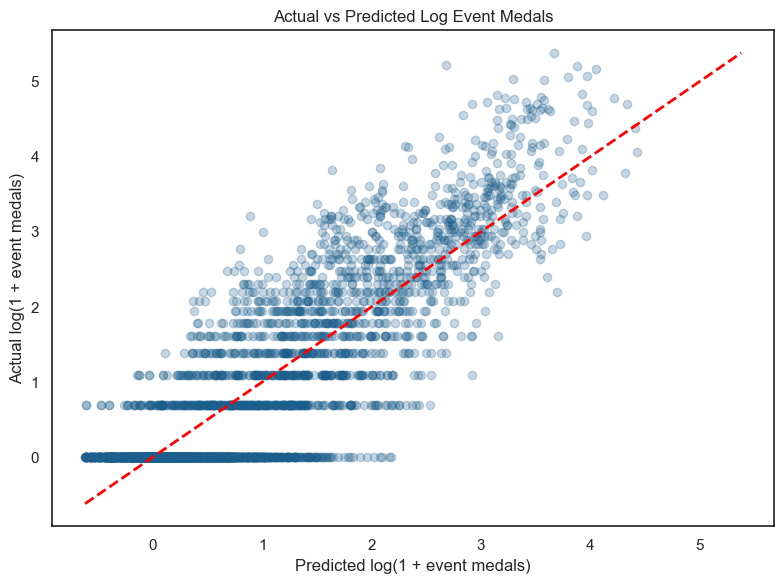

In [57]:

# RQ2(a)-Plot 5) Actual vs predicted values from the multiple regression model
# ----------------------------------------------------------------------------
# This plot checks how closely the model's fitted values match the
# observed log-transformed event-medal counts.

sq1["pred_log_event_medals"] = model_multi.predict(X_multi)
sq1["residuals_multi"] = sq1["log_event_medals"] - sq1["pred_log_event_medals"]

plt.figure(figsize=(8, 6))
plt.scatter(
    sq1["pred_log_event_medals"],
    sq1["log_event_medals"],
    alpha=0.25,
    color="#1D5F8C"
)

min_val = min(sq1["pred_log_event_medals"].min(), sq1["log_event_medals"].min())
max_val = max(sq1["pred_log_event_medals"].max(), sq1["log_event_medals"].max())
plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--", linewidth=2)

plt.title("Actual vs Predicted Log Event Medals")
plt.xlabel("Predicted log(1 + event medals)")
plt.ylabel("Actual log(1 + event medals)")
plt.tight_layout()
plt.savefig("figures/RQ2/rq2_plot05_multiple_regression_actual_vs_predicted.png", dpi=300, bbox_inches="tight")
plt.show()


### Interpretation

This plot compares the **actual** log-transformed medal counts with the **predicted** values from the multiple regression model. The dashed 45-degree line represents **perfect prediction**: points lying close to this line are predicted well, while points farther away indicate larger prediction errors.

Overall, the points follow the 45-degree line reasonably well, which suggests that the multiple regression model captures the broad medal pattern better than a simpler one-predictor model. The alignment is not perfect, but there is a clear positive correspondence between predicted and actual values.

There is still noticeable spread around the line, especially for mid-sized and high-medal country-year observations. This means the model improves fit, but it does not fully explain all variation in Olympic medal outcomes. Some country-years are still underpredicted or overpredicted, showing that additional factors beyond the included predictors may matter.

The horizontal banding appears because the response variable is based on **count data**, and even after log transformation the values remain discrete. Even so, the overall clustering around the diagonal suggests that the multiple regression model provides a more useful summary of medal outcomes than the simpler regression.

Overall, this figure supports the idea that the multiple regression model is a **better fit** than the simple regression, while still leaving room for unexplained variation.

#### Limitations
- Good visual alignment does not mean the model captures every aspect of Olympic medal success.
- The model is still observational and cannot establish causation.
- Because medals are count-based, some banding remains visible even after log transformation.

## RQ2(a) Plot 6: Residual plot for the multiple regression model

### What this plot shows
This residual plot shows the remaining model error after using **log participation size**, **number of sports**, and **year** to predict log-transformed event medals.

### Why this plot is used
This plot checks whether the multiple regression model leaves a more random residual pattern than the simpler model. A more random scatter around zero suggests that the richer model is a better fit.


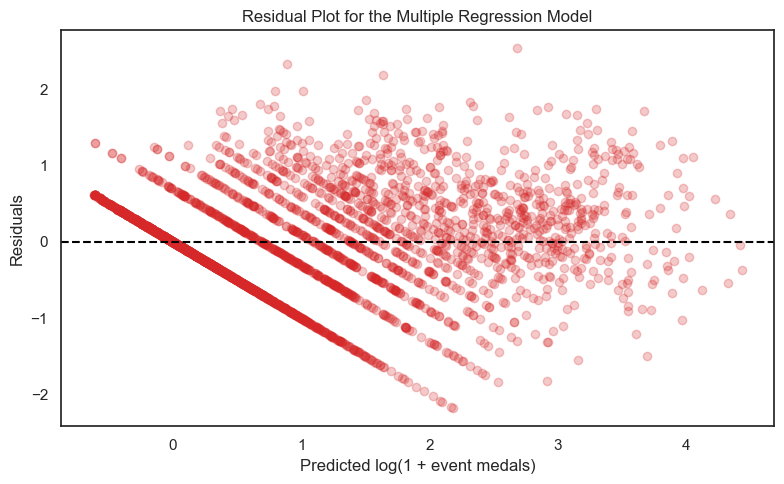

In [58]:

# RQ2(a)-Plot 6) Residual plot for the multiple regression model
# --------------------------------------------------------------
# This residual plot is used to check whether the richer regression
# model leaves less visible structure than the simple model.

plt.figure(figsize=(8, 5))
plt.scatter(
    sq1["pred_log_event_medals"],
    sq1["residuals_multi"],
    alpha=0.25,
    color="#D62828"
)
plt.axhline(0, color="black", linestyle="--")

plt.title("Residual Plot for the Multiple Regression Model")
plt.xlabel("Predicted log(1 + event medals)")
plt.ylabel("Residuals")
plt.tight_layout()
plt.savefig("figures/RQ2/rq2_plot06_multiple_regression_residual_plot.png", dpi=300, bbox_inches="tight")
plt.show()


### Interpretation

This residual plot suggests that the **multiple regression model fits the data better than the simpler regression**, but it is still not perfect. Many residuals are centered around zero, which is a good sign, and the overall spread looks somewhat more balanced than in the simpler one-predictor model.

However, the residuals do **not** form a completely random cloud. There is still visible **banding** and some remaining structure, which means the model does not capture every aspect of the relationship. The banding is expected to some extent because medal outcomes are based on **count data**, so even after log transformation the response remains discrete.

Compared with the simple regression residual plot, the multiple regression residuals appear less dominated by one strong overall pattern. This suggests that adding predictors such as **num_sports** and **year** improves the model by explaining part of the variation that participation size alone could not explain.

At the same time, there is still noticeable spread around zero, especially for observations with moderate to high predicted values. This means the model is better as a summary, but it still leaves meaningful unexplained variation.

Overall, this plot supports the conclusion that the **multiple regression model is more appropriate than the simple regression model** for RQ2(a), while also showing that further improvement would require additional predictors or a different modeling approach.

#### Limitations
- Even an improved residual pattern does not mean the model is complete.
- Unobserved factors such as country strength, host-country effects, sport mix, and historical context may still affect medal outcomes.
- Because medals are count-based, some residual structure remains even after log transformation.

### Conclusion

Overall, the results provide strong evidence of a **positive association** between country-year participation size and event-medal counts. The scatterplots show that countries sending larger delegations generally win more medals, and the fitted regression line confirms this upward relationship.

At the same time, the raw-scale plots also show that the relationship is **not perfectly linear** and becomes more variable for larger delegations. The log-transformed plots improve the visibility of the pattern, reduce compression at low values, and reveal a more stable positive trend, making the relationship easier to model and interpret.

The residual analysis shows that a simple one-predictor regression is useful as an initial summary, but it does not fully capture the structure in the data. Moving to a **multiple regression model** improves the fit by incorporating broader factors such as the number of sports entered and long-run time trends. The actual-versus-predicted and residual plots for the multiple regression suggest that this richer model explains medal outcomes more effectively than the simpler regression, even though some unexplained variation still remains.

Taken together, these results support the conclusion that **participation size is an important predictor of Olympic medal success**, but it is **not a complete explanation on its own**. Countries that send larger delegations tend to win more medals, yet medal outcomes are also shaped by additional structural and historical factors beyond delegation size alone.

## RQ2(b): Which countries are the most efficient at converting participation into medals?

### Short overview
This subsection examines **medal efficiency** at the country level. Instead of focusing only on how many medals a country wins, we ask which countries convert Olympic participation into medal success most effectively.

### Why this question matters
A country can win many medals simply because it sends a very large delegation. Efficiency gives a different perspective by asking how much medal success is achieved **relative to participation size**. This helps distinguish countries that are large from countries that are especially strong at turning participation into results.

### Subquestion
**RQ2(b):** Which countries are the most efficient at converting participation into medals?

### Data preparation / variables used
For this subsection, we use:

- **`team_clean`**: cleaned country/team name
- **`participation_size`**: total number of athlete-event rows for each country
- **`event_medals`**: medal count using the **event-medal method**, where each country-event medal is counted once
- **`num_sports`**: number of distinct sports entered by each country
- **`efficiency`**:

$$
\text{efficiency} = \frac{\text{event medals}}{\text{participation size}}
$$

For readability, efficiency is also reported as **event medals per 100 participation rows**.

To reduce instability from extremely small delegations, we restrict the ranking to countries with at least **100 participation rows**.


In [59]:
# RQ2(b)-1) Build the country-level efficiency table
# --------------------------------------------------
# This step creates one row per country and computes:
# participation size, event-medal count, number of sports entered,
# and medal efficiency measured as event medals per 100 participation rows.

os.makedirs("outputs", exist_ok=True)

required_cols = {"team_clean", "year", "event", "medal", "sports"}
missing_cols = required_cols - set(df.columns)

if missing_cols:
    raise ValueError(f"df is missing required columns: {missing_cols}")

top_n = 25
min_entries = 100

# Keep only medal-winning rows for event-medal counting
medalists = df[df["medal"].isin(["Gold", "Silver", "Bronze"])].copy()

# Count each country-event medal once so team events are not overcounted
event_medals_df = medalists.drop_duplicates(
    subset=["year", "event", "team_clean", "medal"]
).copy()

# Country-level participation size
country_entries = (
    df.groupby("team_clean")
    .size()
    .rename("participation_size")
)

# Country-level event-medal counts
country_event_medals = (
    event_medals_df.groupby("team_clean")
    .size()
    .rename("event_medals")
)

# Number of sports entered by each country
country_num_sports = (
    df.groupby("team_clean")["sports"]
    .nunique()
    .rename("num_sports")
)

# Combine all country-level quantities into one table
efficiency_df = pd.concat(
    [country_entries, country_event_medals, country_num_sports],
    axis=1
).fillna(0).reset_index()

efficiency_df["event_medals"] = efficiency_df["event_medals"].astype(int)
efficiency_df["num_sports"] = efficiency_df["num_sports"].astype(int)

# Efficiency as medals per participation row, then rescaled per 100 rows
efficiency_df["efficiency"] = (
    efficiency_df["event_medals"] / efficiency_df["participation_size"]
)
efficiency_df["event_medals_per_100_entries"] = efficiency_df["efficiency"] * 100

# Filter out very small delegations to avoid unstable efficiency rankings
efficiency_filtered = efficiency_df[
    efficiency_df["participation_size"] >= min_entries
].copy()

# Rank countries by efficiency
all_eff = efficiency_filtered.sort_values(
    "event_medals_per_100_entries", ascending=False
).reset_index(drop=True)

top_eff = all_eff.head(top_n).copy()

print(
    f"Top {top_n} countries by medal efficiency "
    f"(minimum {min_entries} participation rows):"
)

display(
    top_eff[[
        "team_clean", "participation_size", "event_medals",
        "num_sports", "event_medals_per_100_entries"
    ]]
)


Top 25 countries by medal efficiency (minimum 100 participation rows):


,team_clean,participation_size,event_medals,num_sports,event_medals_per_100_entries
0,Russia,10042,1873,66,18.651663
1,United States,16681,2939,79,17.618848
2,Azerbaijan,383,59,28,15.404700
3,Ethiopia,408,61,7,14.950980
4,Kenya,801,116,18,14.481898
5,China,5171,740,65,14.310578
6,Georgia,356,49,28,13.764045
7,Germany,14396,1819,72,12.635454
8,Norway,4492,482,52,10.730187
9,Cuba,2221,237,32,10.670869


## RQ2(b) Plot 1: Top countries ranked by medal efficiency

### What this plot shows
This plot ranks the **top 25 countries** by **event medals per 100 participation rows**.

### Why this plot is used
A ranking plot makes it easy to identify which countries achieve the strongest medal return relative to the size of their Olympic participation. It directly answers the efficiency question without being dominated by the largest delegations.


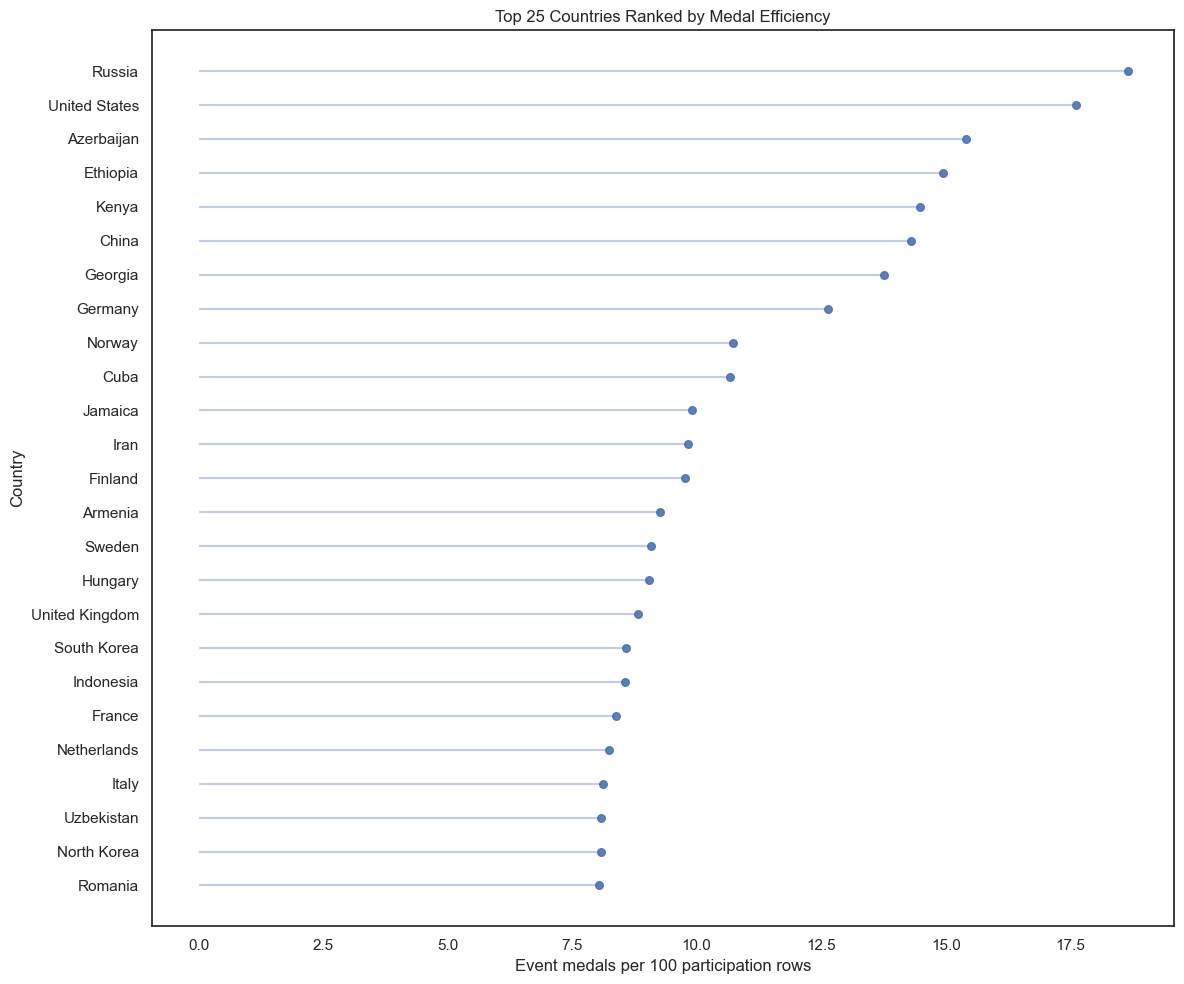

In [60]:
# RQ2(b)-Plot 1) Rank the top 25 countries by medal efficiency
# -------------------------------------------------------------
# This lollipop plot highlights which countries achieve the
# highest event-medal return relative to participation size.

plt.figure(figsize=(12, max(10, len(top_eff) * 0.28)))
y_pos = np.arange(len(top_eff))

plt.hlines(
    y=y_pos,
    xmin=0,
    xmax=top_eff["event_medals_per_100_entries"],
    alpha=0.35
)
plt.scatter(
    top_eff["event_medals_per_100_entries"],
    y_pos,
    s=30,
    alpha=0.9
)

plt.yticks(y_pos, top_eff["team_clean"])
plt.gca().invert_yaxis()
plt.title(f"Top {top_n} Countries Ranked by Medal Efficiency")
plt.xlabel("Event medals per 100 participation rows")
plt.ylabel("Country")
plt.tight_layout()
plt.savefig("figures/RQ2/rq2_plot07_top_countries_by_medal_efficiency.png", dpi=300, bbox_inches="tight")
plt.show()


### Interpretation

This ranking shows which countries convert participation into medals most efficiently after applying the minimum-size filter. Countries near the top of the list achieve the largest number of **event medals per 100 participation rows**, which means they produce strong medal outcomes relative to the scale of their Olympic participation.

Several highly ranked countries are not necessarily the very largest delegations. This suggests that medal efficiency is not determined only by size; it can also reflect strong performance concentration, successful specialization in particular sports, or consistently high-quality results across the events a country enters.

At the same time, efficiency should be interpreted carefully. A country can rank highly because it wins many medals with a moderate delegation, but it may also compete in fewer sports or focus on events where it is historically strong.

#### Limitations
- Efficiency is based on **athlete-event rows**, not exact unique athletes.
- The ranking is sensitive to the minimum participation threshold.
- A high efficiency value does not necessarily mean broad overall dominance; it reflects medal return relative to participation size.


## RQ2(b) Plot 2: Participation size vs event medals, with efficient countries highlighted

### What this plot shows
This scatterplot shows the relationship between **participation size** and **event medals**, while highlighting the countries that rank among the top 25 in medal efficiency.

### Why this plot is used
The ranking plot identifies efficient countries, but this figure shows **where those countries sit in the overall participation–medal space**. It helps distinguish countries that are efficient because they achieve strong medal totals with moderate delegations from those that are both large and efficient.


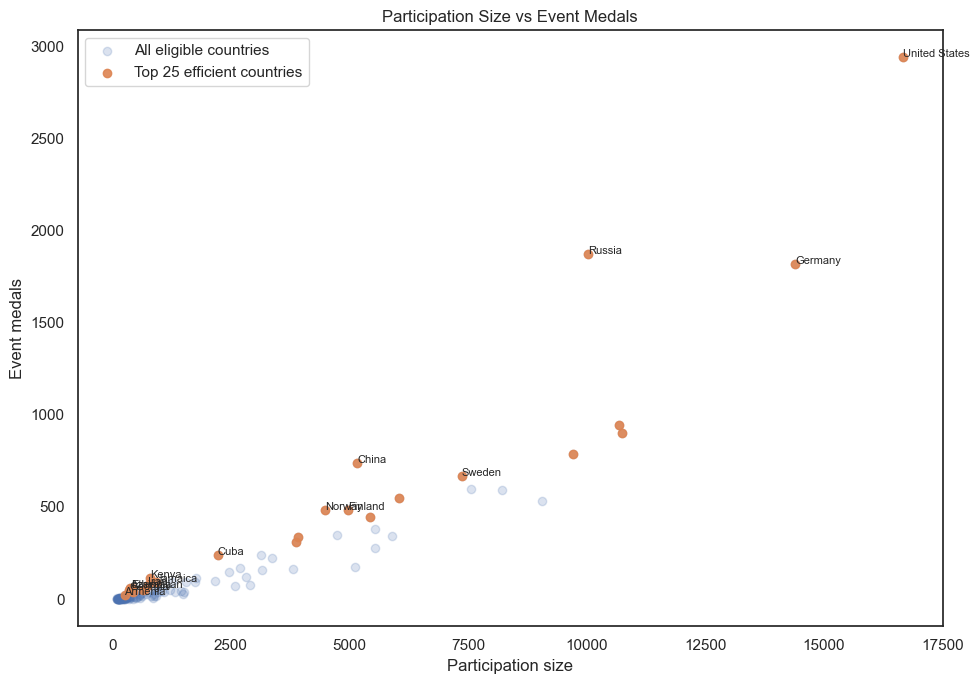

In [61]:
# RQ2(b)-Plot 2) Participation size vs event medals with efficient countries highlighted
# --------------------------------------------------------------------------------------
# This plot places the most efficient countries inside the full country-level
# participation–medal relationship so their efficiency can be interpreted in context.

plt.figure(figsize=(10, 7))

# All eligible countries after the minimum-size filter
plt.scatter(
    efficiency_filtered["participation_size"],
    efficiency_filtered["event_medals"],
    alpha=0.20,
    label="All eligible countries"
)

# Highlight the top 25 efficient countries
plt.scatter(
    top_eff["participation_size"],
    top_eff["event_medals"],
    alpha=0.90,
    label=f"Top {top_n} efficient countries"
)

# Label the top 15 efficient countries to reduce clutter
for _, row in top_eff.head(15).iterrows():
    plt.text(
        row["participation_size"],
        row["event_medals"],
        row["team_clean"],
        fontsize=8
    )

plt.title("Participation Size vs Event Medals")
plt.xlabel("Participation size")
plt.ylabel("Event medals")
plt.legend()
plt.tight_layout()
plt.savefig("figures/RQ2/rq2_plot08_efficiency_countries_highlighted_in_participation_vs_medals.png", dpi=300, bbox_inches="tight")
plt.show()


### Interpretation

This plot shows that the most efficient countries are not all concentrated in one single part of the participation–medal relationship. Some highlighted countries achieve strong medal totals with **moderate participation sizes**, while others combine **large delegations** with strong medal production.

This means efficiency can arise in more than one way. Some countries appear efficient because they win many medals without sending extremely large delegations, while others remain efficient even at a much larger scale. In that sense, the highlighted countries stand out not simply because they participate a lot, but because their medal return is strong relative to their participation size.

The figure also helps separate **efficiency** from **absolute size**. Very large delegations may win many medals, but they are not automatically the most efficient. Likewise, moderate-sized delegations can still appear near the top of the efficiency ranking if they convert entries into medals unusually well.

#### Limitations
- Only the top 15 highlighted countries are labeled to avoid clutter.
- The plot is descriptive and does not show why a country is efficient.
- Countries may appear efficient for different structural reasons, such as sport specialization or historical strength, which are not directly measured here.


### conclusion

Overall, the efficiency analysis shows that some countries achieve unusually strong medal returns relative to the size of their Olympic participation. The ranking plot identifies the most efficient countries directly, while the participation–medal scatterplot shows that these countries can stand out either through strong medal production with moderate delegation sizes or through maintaining efficiency even at larger scales.

Taken together, the results suggest that Olympic success is not only about sending the largest delegation. Some countries appear especially effective at converting participation into medal outcomes, which supports the idea that **efficiency** provides a distinct perspective from total medal count alone.

## RQ2(c): Which countries dominate the Olympic Games in a given year, and is this dominance primarily driven by delegation size or efficiency?


### Short overview

This subsection examines **Olympic dominance** at the country-year level. Instead of looking only at total participation or overall long-run medal accumulation, it asks which countries finished with the highest **event-medal count** in each Olympic year and how concentrated that dominance was across the 21st century.

### Why this question matters

A country can appear successful in two different ways: by sending a **very large delegation**, or by converting participation into medals **efficiently**. Studying dominance year by year helps show whether Olympic success is concentrated in a few countries and whether repeated dominance seems to come mainly from scale, efficiency, or a combination of both.

### Subquestion

**RQ2(c):** Which countries dominate the Olympic Games in a given year, and is this dominance primarily driven by delegation size or efficiency?

### Data preparation / variables used

For this subsection, we use:

- **`year`**: Olympic year
- **`team_clean` / `team`**: cleaned country/team label
- **`event_medals`**: each country-event medal counted once, so team events are not overcounted
- **`participation_size`**: number of athlete-event rows, used as a proxy for delegation scale
- **21st-century Olympic years**:  
  `2000, 2002, 2004, 2006, 2008, 2010, 2012, 2014, 2016, 2020, 2022, 2024`


### RQ2(c)-Plot 1) Top country by event medals in each Olympic year (2000-2024)

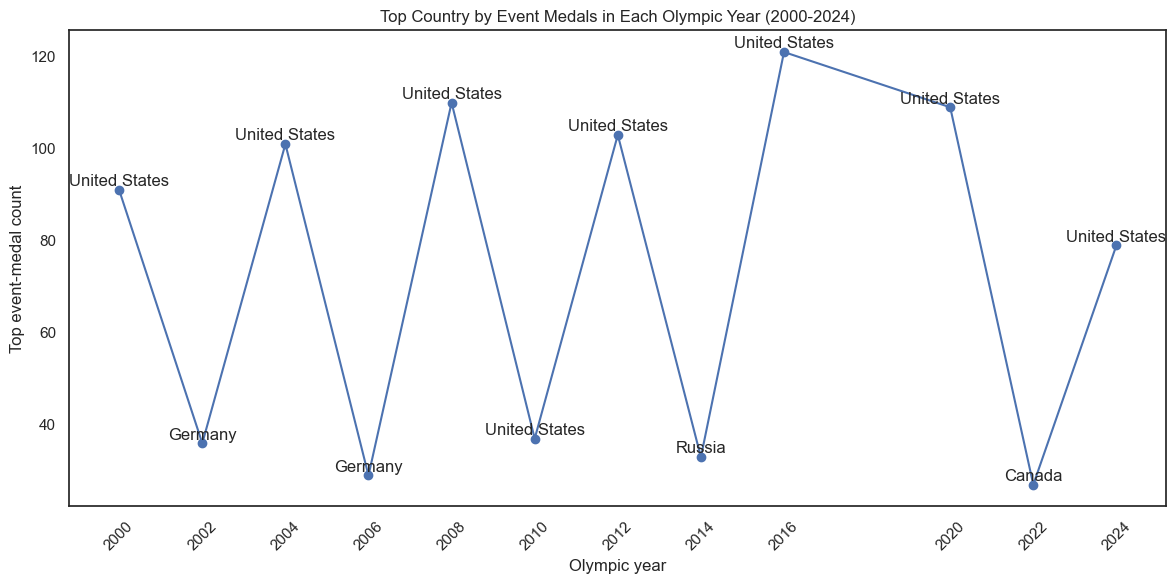

Top country in each Olympic year:


,year,team_clean,event_medals
0,2000,United States,91
1,2002,Germany,36
2,2004,United States,101
3,2006,Germany,29
4,2008,United States,110
5,2010,United States,37
6,2012,United States,103
7,2014,Russia,33
8,2016,United States,121
9,2020,United States,109


In [62]:
# RQ2(c)-Plot 1) Top country by event medals in each Olympic year (2000-2024)
# ----------------------------------------------------------------------------
# This step identifies the country with the highest event-medal count in each
# Olympic year in the 21st-century subset of the dataset.

# Keep only 21st-century Olympic years
years_21st = [2000, 2002, 2004, 2006, 2008, 2010, 2012, 2014, 2016, 2020, 2022, 2024]
df_21 = df_clean[df_clean["year"].isin(years_21st)].copy()

# Count event medals by year and country
# Each country-event medal is counted once to avoid overcounting team events.
event_medals = (
    df_21[df_21["medal"].isin(["Gold", "Silver", "Bronze"])]
    .drop_duplicates(subset=["team_clean", "event", "year", "medal"])
    .groupby(["year", "team_clean"])
    .size()
    .rename("event_medals")
    .reset_index()
)

# Identify the top country in each Olympic year
top_country_each_year = (
    event_medals.sort_values(["year", "event_medals"], ascending=[True, False])
    .groupby("year")
    .first()
    .reset_index()
)

# Create the line plot
plt.figure(figsize=(12, 6))
plt.plot(
    top_country_each_year["year"],
    top_country_each_year["event_medals"],
    marker="o"
)

# Label each point with the country name
for _, row in top_country_each_year.iterrows():
    plt.text(
        row["year"],
        row["event_medals"] + 0.8,
        row["team_clean"],
        ha="center"
    )

plt.title("Top Country by Event Medals in Each Olympic Year (2000-2024)")
plt.xlabel("Olympic year")
plt.ylabel("Top event-medal count")
plt.xticks(years_21st, rotation=45)
plt.tight_layout()
plt.savefig("figures/RQ2/rq2_plot09_top_country_by_event_medals_in_each_olympic_year.png", dpi=300, bbox_inches="tight")
plt.show()

# Display the year-by-year dominance table
print("Top country in each Olympic year:")
display(top_country_each_year)


### Interpretation

This plot shows which country had the highest **event-medal count** in each Olympic year from 2000 to 2024. The labels make it easy to see whether dominance is shared across several countries or concentrated in one recurring leader.

The pattern suggests that dominance is **not evenly distributed** across countries. The **United States** appears most frequently as the top country, while **Russia**, **Germany**, and **Canada** appear as leaders in selected years. This indicates that a small group of countries account for most of the top positions in the 21st-century record.

The height of each point also matters. In some years, the top country’s event-medal total is much higher than in other years, which suggests that the strength of dominance varies over time. Years with especially high top counts point to stronger separation between the leader and the rest of the field.

This figure is descriptive, but it helps frame the main dominance question: repeated top finishes seem to come from countries that combine **large-scale participation** with strong medal conversion, rather than from one-time efficiency alone.

#### Limitations
- The dataset is missing the **2018 Winter Olympics**, so the 21st-century timeline is incomplete.
- This plot identifies the top country only; it does not show the gap between first place and the rest of the field.
- The figure mixes Summer and Winter Olympic years, so the scale of top medal counts is not directly comparable across all years.


### RQ2(c)-Plot 2) Share of Olympic years dominated by each country (2000-2024)

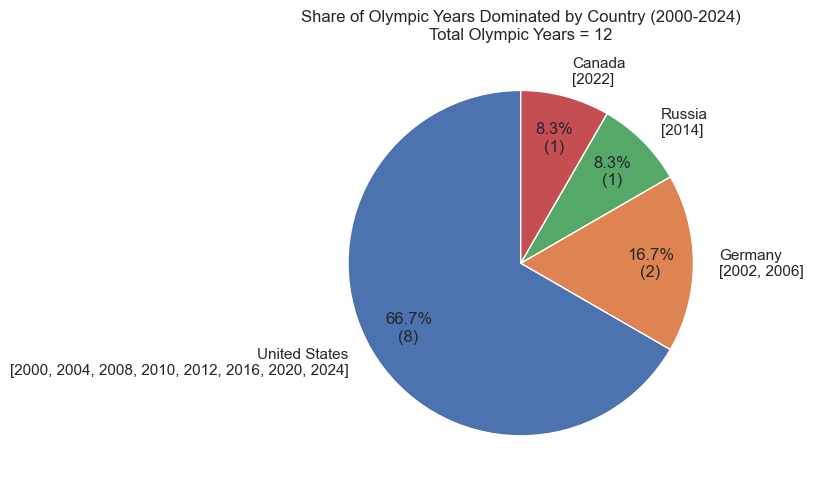

In [63]:
# ---------------------------------------------------------------------------
# This plot summarizes how often each country appeared as the top event-medal
# country across the 21st-century Olympic years used in the analysis.

plt.figure(figsize=(8, 8))

# Count how many Olympic years each country dominated
dominance_counts = top_country_each_year["team_clean"].value_counts()

# Total number of Olympic years in the analysis
total_years = len(top_country_each_year)

# Store the exact years dominated by each country
country_years = (
    top_country_each_year.groupby("team_clean")["year"]
    .apply(list)
    .to_dict()
)

# Helper function for percentage + count labels inside the pie slices
def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        count = int(round(pct * total / 100.0))
        return f"{pct:.1f}%\n({count})"
    return my_autopct

# Labels include country name and dominated years
pie_labels = [
    f"{country}\n{country_years[country]}"
    for country in dominance_counts.index
]

plt.pie(
    dominance_counts.values,
    labels=pie_labels,
    autopct=make_autopct(dominance_counts.values),
    startangle=90,
    labeldistance=1.15,
    pctdistance=0.75
)

plt.title(
    "Share of Olympic Years Dominated by Country (2000-2024)\n"
    f"Total Olympic Years = {total_years}")

plt.tight_layout()
plt.savefig("figures/RQ2/rq2_plot10_share_of_olympic_years_dominated_by_country.png", dpi=300, bbox_inches="tight")
plt.show()


### Interpretation

This pie chart shows how concentrated Olympic dominance is across the 21st-century years included in the dataset. A larger slice means that a country finished first in **more Olympic years**, not just that it had one especially strong performance.

The chart shows that dominance is **highly concentrated**, with the **United States** accounting for the largest share of top finishes. **Russia** and **Germany** appear next, while **Canada** appears as the leading country in only one of the years shown. This suggests that long-run Olympic dominance is driven by a relatively small number of countries rather than being widely shared.

When this result is read together with **RQ2(a)** and **RQ2(b)**, it suggests that repeated dominance is usually associated with **both**:
- large participation size, which creates more medal opportunities, and
- the ability to convert those opportunities into medals efficiently.

In other words, dominance does not appear to come from delegation size alone. The countries that dominate repeatedly are generally strong on both **scale** and **medal conversion**.

### Short subsection conclusion

Overall, the dominance analysis shows that Olympic leadership in the 21st century is concentrated in a small number of countries, with the **United States** appearing most often as the top country by event-medal count. This supports the idea that Olympic dominance is shaped by a combination of **delegation size** and **medal efficiency**, rather than by participation alone.

#### Limitations
- The dataset does not include the **2018 Winter Olympics**, so the dominance record is incomplete.
- Summer and Winter Olympics are combined, which limits direct year-to-year comparability.



# Research Question 3

## What factors influence an athlete’s probability of winning a medal, and to what extent does country/team membership contribute to medal probability after accounting for athlete characteristics?

This research question shifts the focus from country-year medal totals to the **athlete-event-row level**. It asks how medal probability changes with athlete characteristics such as **age, sex, and sport**, and then tests whether **country/team membership** still adds explanatory power after those athlete-level factors are already included.

This question matters because Olympic success is not determined only by how many athletes a country sends. It may also depend on **who the athletes are**, **which sports they compete in**, and whether some countries retain an advantage even after those athlete-level differences are taken into account.

We divide this research question into two focused subquestions so that each one addresses a specific part of the main question in detail:

- **RQ3(a):** How do **age, sex, and sport** affect an athlete’s probability of winning a medal?
- **RQ3(b):** After controlling for **age, sex, and sport**, which countries/teams still exhibit higher or lower baseline medal probability, and does country/team membership explain meaningful variation in medal outcomes?



## RQ3(a): How do age, sex, and sport affect an athlete’s probability of winning a medal?

### Short overview
This subsection studies medal probability at the **athlete-event-row** level. It begins with a descriptive graph that combines **sport category**, **sex**, and a visible summary of **dominant age range**, and then fits a **base logistic regression model** using athlete-level predictors only.

### Why this question matters
Age, sex, and sport are three of the most important athlete characteristics in Olympic data. Understanding how medal probability changes across these factors helps explain whether some sports favor different peak age ranges, whether medal rates differ by sex, and how much of medal success can already be explained before country/team is added.

### Subquestion
**RQ3(a):** How do **age, sex, and sport** affect an athlete’s probability of winning a medal?

### Data preparation / variables used
For this subsection, we use:

- **`age`**: numeric athlete age used in the regression model
- **`age_bin`**: broad age groups used only for the descriptive graph
- **`sex`**: male (**M**) and female (**F**)
- **`sports`**: original sport names from the dataset
- **`sport_category`**: grouped sport families created for readability
- **`won_medal`**: binary response variable where **1 = medal** and **0 = no medal**

The regression model uses **age as a numeric variable** with an additional **quadratic age term** so that the relationship can capture curved peak-age patterns.


### RQ3(a)-1: Prepare the athlete-level dataset

This step builds the athlete-level dataset used in **RQ3(a)**. It:

- keeps the variables needed for the analysis,
- creates the binary response variable **`won_medal`**,
- restricts the data to plausible athlete ages,
- and reuses the **feature-engineered sport variables** created earlier in the notebook.


In [64]:
# RQ3(a)-1) Prepare the athlete-level dataset
# This step prepares the athlete-level data used in RQ3(a).
# Cleaned sport labels and grouped sport categories were created earlier
# in the feature-engineering section and are reused here.

sns.set_theme(style="whitegrid")

# Ensure the cleaned dataframe exists
if "df_clean" not in globals():
    if "df" not in globals():
        raise NameError("Neither 'df_clean' nor raw 'df' is available. Run the data-loading cell first.")
    df_clean = df.copy()

# If sport variables were not created earlier, rebuild them now
if "sports_clean" not in df_clean.columns or "sport_category" not in df_clean.columns:
    if "sport_fix" not in globals() or "group_sport_category" not in globals():
        raise NameError("Sport feature-engineering objects are missing. Run cell 7E before RQ3(a).")
    df_clean["sports_clean"] = (
        df_clean["sports"]
        .astype(str)
        .str.strip()
        .replace(sport_fix)
    )
    df_clean["sport_category"] = df_clean["sports_clean"].apply(group_sport_category)

rq3a = df_clean.copy()

# Keep only the columns needed for this subquestion
rq3a = rq3a[["age", "sex", "sports_clean", "sport_category", "medal","team_clean"]].copy()

# Basic cleaning
rq3a["age"] = pd.to_numeric(rq3a["age"], errors="coerce")
rq3a["sex"] = rq3a["sex"].astype(str).str.strip()
rq3a["medal"] = rq3a["medal"].astype(str).str.strip()

rq3a["sex"] = rq3a["sex"].replace(["nan", "None", ""], np.nan)
rq3a["medal"] = rq3a["medal"].replace(["nan", "None", ""], np.nan)

# Keep rows with complete predictor information
rq3a = rq3a.dropna(subset=["age", "sex", "sport_category"]).copy()

# Restrict to a plausible athlete age range
rq3a = rq3a[(rq3a["age"] >= 10) & (rq3a["age"] <= 60)].copy()

# Keep standard sex codes only
rq3a = rq3a[rq3a["sex"].isin(["M", "F"])].copy()

# Binary medal outcome
rq3a["won_medal"] = np.where(
    rq3a["medal"].isin(["Gold", "Silver", "Bronze"]),
    1,
    0
)

print("RQ3(a) working shape:", rq3a.shape)
print("\nSport-category counts:")
print(rq3a["sport_category"].value_counts())


RQ3(a) working shape: (245844, 7)

Sport-category counts:
sport_category
Winter Sports         40548
Athletics / Urban     39563
Aquatics              29142
Combat                27964
Gymnastics            22240
Team Sports           21994
Boating / Rowing      20248
Precision Sports      13632
Strength / Mixed      11905
Cycling               10338
Racquet Sports         6725
Other / Historical     1545
Name: count, dtype: int64



### RQ3(a)-2: Create age groups for the descriptive graph

The regression model uses **numeric age** because that is more appropriate for logistic regression.

For the descriptive figure, however, broad **age bins** are easier to read than raw ages. These age groups allow the graph to show a readable summary of how medal rates vary across **sport category**, **sex**, and the most prominent **age range** in each bar.


In [65]:
# RQ3(a)-2) Create ordered age bins for descriptive plotting
# ----------------------------------------------------------
# This cell creates the age-bin variable used to label the descriptive
# medal-rate plot in RQ3(a).

age_bin_order = ["<16", "16-18", "19-21", "22-24", "25-27", "28-30", "31-35", "36-40", "41-50", "51+"]
age_bin_edges = [0, 15, 18, 21, 24, 27, 30, 35, 40, 50, 100]

rq3a["age_bin"] = pd.cut(
    rq3a["age"],
    bins=age_bin_edges,
    labels=age_bin_order,
    right=True
)

rq3a["age_bin"] = pd.Categorical(
    rq3a["age_bin"],
    categories=age_bin_order,
    ordered=True
)

print("RQ3(a) age-bin distribution:")
display(rq3a["age_bin"].value_counts(dropna=False).sort_index())


RQ3(a) age-bin distribution:


age_bin
<16       2757
16-18    15509
19-21    41591
22-24    58133
25-27    50724
28-30    34848
31-35    27096
36-40     8960
41-50     5163
51+       1063
Name: count, dtype: int64

### RQ3(a)-3: Plot 1 — Medal rate by grouped sport category and sex

#### What this plot shows 
This plot summarizes medal rates across the grouped sport categories separately for **male** and **female** athlete-event rows. Each bar represents the average medal rate within one **sport category × sex** combination. The label inside each bar shows the **dominant age bin**, meaning the age group with the highest medal rate within that sport category and sex. 

#### Why this plot is used 
This figure gives a compact descriptive summary of how medal outcomes differ across: - **sport category**, - **sex**, and - **dominant age group**. It is useful because it combines all three ideas into one readable figure before fitting the logistic regression model.

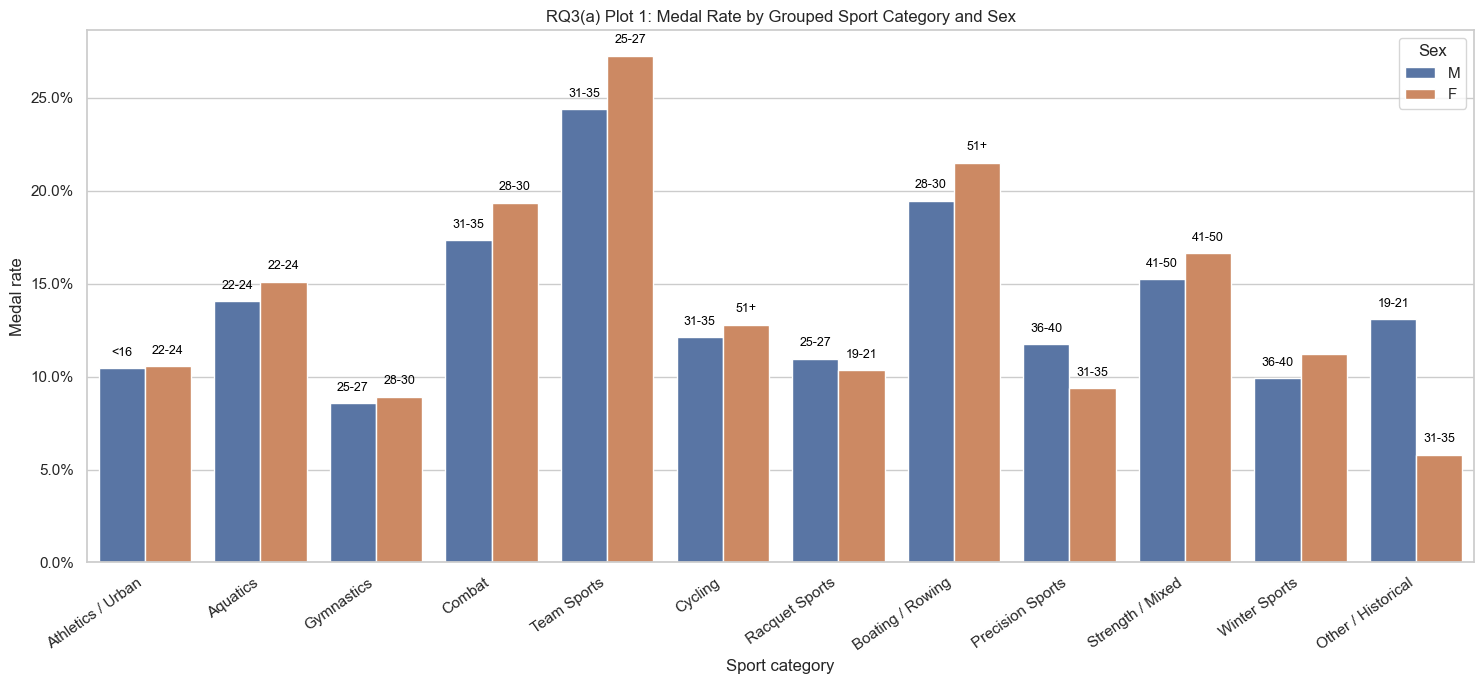

Bar-level summary with dominant age bins:


,sport_category,sex,athlete_event_rows,medal_count,medal_rate,dominant_age_bin
2,Athletics / Urban,F,13276,1401,0.1055,<16
3,Athletics / Urban,M,26287,2749,0.1046,22-24
0,Aquatics,F,12465,1883,0.1511,25-27
1,Aquatics,M,16677,2342,0.1404,31-35
10,Gymnastics,F,8405,750,0.0892,31-35
11,Gymnastics,M,13835,1186,0.0857,31-35
6,Combat,F,4726,915,0.1936,25-27
7,Combat,M,23238,4027,0.1733,28-30
20,Team Sports,F,7146,1948,0.2726,36-40
21,Team Sports,M,14848,3622,0.2439,41-50


In [67]:
# RQ3(a)-3) Build a descriptive plot with dominant age-bin labels
# ---------------------------------------------------------------
# This plot summarizes medal rate by grouped sport category and sex.
# Each bar is labeled with the age bin that has the highest medal rate
# within that sport category × sex group.

from matplotlib.ticker import PercentFormatter

# Step 1) Compute overall medal rate by sport category and sex
bar_data = (
    rq3a.groupby(["sport_category", "sex"], observed=True)
        .agg(
            athlete_event_rows=("won_medal", "size"),
            medal_count=("won_medal", "sum"),
            medal_rate=("won_medal", "mean")
        )
        .reset_index()
)

# Step 2) Compute medal rate by sport category, sex, and age bin
age_bin_data = (
    rq3a.groupby(["sport_category", "sex", "age_bin"], observed=True)
        .agg(
            athlete_event_rows=("won_medal", "size"),
            medal_count=("won_medal", "sum"),
            medal_rate=("won_medal", "mean")
        )
        .reset_index()
)

# Step 3) Remove small age-bin groups so dominant labels are more stable
age_bin_data = age_bin_data[age_bin_data["athlete_event_rows"] >= 50].copy()

# Step 4) Keep the age bin with the highest medal rate
dominant_age_bins = (
    age_bin_data.sort_values(
        ["sport_category", "sex", "medal_rate"],
        ascending=[True, True, False]
    )
    .drop_duplicates(subset=["sport_category", "sex"])
    [["sport_category", "sex", "age_bin"]]
    .rename(columns={"age_bin": "dominant_age_bin"})
)

# Step 5) Merge dominant age-bin labels into the bar plot data
bar_data = bar_data.merge(
    dominant_age_bins,
    on=["sport_category", "sex"],
    how="left"
)

sport_order = [
    "Athletics / Urban",
    "Aquatics",
    "Gymnastics",
    "Combat",
    "Team Sports",
    "Cycling",
    "Racquet Sports",
    "Boating / Rowing",
    "Precision Sports",
    "Strength / Mixed",
    "Winter Sports",
    "Other / Historical"
]

# Step 6) Apply consistent ordering
bar_data["sport_category"] = pd.Categorical(
    bar_data["sport_category"],
    categories=sport_order,
    ordered=True
)
bar_data = bar_data.sort_values(["sport_category", "sex"]).copy()

# Step 7) Draw plot
plt.figure(figsize=(15, 7))
ax = sns.barplot(
    data=bar_data,
    x="sport_category",
    y="medal_rate",
    hue="sex",
    hue_order=["M", "F"]
)

# Step 8) Titles and labels
plt.title("RQ3(a) Plot 1: Medal Rate by Grouped Sport Category and Sex")
plt.xlabel("Sport category")
plt.ylabel("Medal rate")
plt.xticks(rotation=35, ha="right")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))

# Step 9) Add dominant age-bin labels above bars
for patch, (_, row) in zip(ax.patches, bar_data.iterrows()):
    height = patch.get_height()
    x = patch.get_x() + patch.get_width() / 2

    if pd.notna(row["dominant_age_bin"]):
        ax.text(
            x,
            height + 0.005,
            str(row["dominant_age_bin"]),
            ha="center",
            va="bottom",
            fontsize=9,
            color="black"
        )

plt.legend(title="Sex")
plt.tight_layout()
plt.savefig("figures/RQ3/rq3_plot01_medal_rate_by_grouped_sport_category_and_sex.png", dpi=300, bbox_inches="tight")
plt.show()

print("Bar-level summary with dominant age bins:")
display(bar_data.sort_values(["sport_category", "sex"]).round(4))

### Interpretation

This plot shows that medal rates vary across grouped sport categories and between male and female athlete-event rows. Team Sports, Boating / Rowing, and Combat have relatively high medal rates, while categories such as Gymnastics, Winter Sports, and Precision Sports tend to have lower rates in this grouped summary.

The dominant age-bin labels suggest that the age group with the highest medal rate differs across sport categories and sex groups. This indicates that peak medal-winning age is not constant across sports, which supports the idea that age and sport category should both be included in the medal-probability model.

Overall, this descriptive figure suggests that **age, sex, and sport category** are all relevant predictors of medal success and therefore provide a strong motivation for the logistic regression model used later in RQ3(a).

#### Limitations
- The dominant age-bin label is descriptive and does not imply causation.
- Grouping many sports into broader sport categories improves readability but can hide within-category variation.
- Even after filtering smaller age-bin groups, some dominant labels may still be influenced by uneven sample sizes.


### RQ3(a)-4: Fit the base logistic regression model

Because **`won_medal`** is binary, logistic regression is the appropriate model for RQ3(a).

The model includes:
- **age**,
- **age²**, to allow a curved age pattern,
- **sex**, and
- **grouped sport category**.

This is the **base athlete-level model** for RQ3(a). Country/team effects are intentionally excluded here so that the contribution of athlete characteristics can be studied first.


In [ ]:
# RQ3(a)-4) Fit the base athlete-level logistic regression model

rq3a_model = smf.logit(
    formula="won_medal ~ age + I(age**2) + C(sex) + C(sport_category)",
    data=rq3a
).fit(disp=False)

print(rq3a_model.summary())


                           Logit Regression Results                           
Dep. Variable:              won_medal   No. Observations:               245844
Model:                          Logit   Df Residuals:                   245829
Method:                           MLE   Df Model:                           14
Date:                Thu, 02 Apr 2026   Pseudo R-squ.:                 0.02424
Time:                        15:53:42   Log-Likelihood:                -97501.
converged:                       True   LL-Null:                       -99924.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                              coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------
Intercept                                  -2.9312      0.084    -34.828      0.000      -3.096      -2.766
C(sex)[T.M]                                -


### RQ3(a)-5: Convert logistic coefficients to odds ratios

Odds ratios make the logistic-regression results easier to interpret:

- **odds ratio > 1** means higher medal odds,
- **odds ratio < 1** means lower medal odds,
- **odds ratio = 1** means no change in odds relative to the reference level.

This table helps translate the model coefficients into a form that is more directly useful for discussing medal probability.


In [ ]:

# RQ3(a)-5) Convert logistic coefficients to odds ratios

params = rq3a_model.params
conf = rq3a_model.conf_int()
conf.columns = ["2.5%", "97.5%"]

rq3a_odds = pd.DataFrame({
    "coefficient": params,
    "odds_ratio": np.exp(params),
    "OR_2.5%": np.exp(conf["2.5%"]),
    "OR_97.5%": np.exp(conf["97.5%"]),
    "p_value": rq3a_model.pvalues
})

print(rq3a_odds.round(4))


                                         coefficient  odds_ratio  OR_2.5%  \
Intercept                                    -2.9312      0.0533   0.0452   
C(sex)[T.M]                                  -0.1047      0.9006   0.8780   
C(sport_category)[T.Athletics / Urban]       -0.4567      0.6334   0.6042   
C(sport_category)[T.Boating / Rowing]         0.2974      1.3464   1.2818   
C(sport_category)[T.Combat]                   0.1611      1.1748   1.1213   
C(sport_category)[T.Cycling]                 -0.2592      0.7717   0.7208   
C(sport_category)[T.Gymnastics]              -0.5995      0.5491   0.5186   
C(sport_category)[T.Other / Historical]      -0.2101      0.8105   0.6889   
C(sport_category)[T.Precision Sports]        -0.4060      0.6663   0.6236   
C(sport_category)[T.Racquet Sports]          -0.4621      0.6300   0.5786   
C(sport_category)[T.Strength / Mixed]        -0.0186      0.9816   0.9221   
C(sport_category)[T.Team Sports]              0.5952      1.8134   1.7313   


### Interpretation

The descriptive graph shows that medal rates are not uniform across sport categories. Some grouped sports have noticeably higher medal rates than others, and the dominant age-bin labels suggest that the strongest medal-winning age range also varies across sports and, in some cases, across sex.

The logistic-regression model then evaluates these athlete characteristics simultaneously. In this framework, **age** captures the overall age effect, **age²** allows that effect to curve rather than remain strictly linear, **sex** measures the difference between male and female athlete-event rows after controlling for the other variables, and **sport category** compares medal odds across grouped sports.

The odds-ratio table should be interpreted as the main model-based result for this subsection. Terms with odds ratios above 1 are associated with higher medal odds, while terms below 1 are associated with lower medal odds relative to the chosen reference level. Together, the graph and model provide both a descriptive and a statistical view of athlete-level medal probability.

#### Limitations
- This analysis is conducted at the **athlete-event-row** level rather than the unique-athlete level.
- Grouping sports improves readability, but it also hides some sport-specific detail.
- The logistic model explains association, not causation.

### conclusion
Overall, RQ3(a) shows that medal probability varies meaningfully with **age, sex, and sport**. The descriptive graph highlights visible differences in medal rates and dominant age ranges across sport categories, while the logistic regression confirms that athlete-level characteristics provide important information about medal probability even before country/team effects are added.


## RQ3(b): After controlling for age, sex, and sport, which countries/teams still exhibit higher or lower baseline medal probability, and does country/team membership explain meaningful variation in medal outcomes?

### Short overview
This subsection keeps the athlete-level predictors from **RQ3(a)** and then adds **country/team membership** to the logistic-regression model. The goal is to test whether country/team still improves medal prediction after age, sex, and sport have already been taken into account.

### Why this question matters
If country/team membership still matters after controlling for athlete characteristics, that suggests Olympic success depends on more than individual athlete profiles alone. It would indicate that some countries retain an additional advantage that is not fully explained by age, sex, or sport category.

### Subquestion
**RQ3(b):** After controlling for **age, sex, and sport**, which countries/teams still show higher or lower baseline medal probability, and does country/team membership explain meaningful variation in medal outcomes?

### Data preparation / variables used
For this subsection, we use:

- **`won_medal`**: binary medal outcome (**1 = medal**, **0 = no medal**)
- **`age`** and **`age_sq`**: numeric age terms used to allow a curved age pattern
- **`sex`**: athlete sex (**F** or **M**)
- **`sport_category`**: grouped sport category from the feature-engineering section
- **`team_clean`**: cleaned country/team variable used for the country-adjusted model

To keep the country analysis stable and readable, the model and plots focus on the **30 most frequent countries/teams** in the cleaned athlete-level data.


### RQ3(b)-1: Prepare the country-adjusted modeling dataset

This step cleans the athlete-level variables, creates the country/team variable used for adjustment, and keeps the most frequent countries/teams so the country effects remain interpretable.


In [ ]:
# RQ3(b)-1) Import the tools used in the course-aligned logistic-regression workflow

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)


In [ ]:
# RQ3(b)-1A) Clean the athlete-level and country/team variables
# -----------------------------------------------------------
# This step prepares the athlete-level dataset used in the
# country-adjusted logistic-regression analysis.

# Ensure the cleaned dataframe exists
if "df_clean" not in globals():
    if "df" not in globals():
        raise NameError("Neither 'df_clean' nor raw 'df' is available. Run the data-loading cell first.")
    df_clean = df.copy()

# If sport variables were not created earlier, rebuild them now
if "sports_clean" not in df_clean.columns or "sport_category" not in df_clean.columns:
    if "sport_fix" not in globals() or "group_sport_category" not in globals():
        raise NameError("Sport feature-engineering objects are missing. Run cell 7E before RQ3(b).")
    df_clean["sports_clean"] = (
        df_clean["sports"]
        .astype(str)
        .str.strip()
        .replace(sport_fix)
    )
    df_clean["sport_category"] = df_clean["sports_clean"].apply(group_sport_category)

rq3b = df_clean.copy()

# Keep the variables needed for the country-adjusted model
keep_cols = ["age", "sex", "medal", "sport_category", "team"]
rq3b = rq3b[keep_cols].copy()

# Basic cleaning
rq3b["age"] = pd.to_numeric(rq3b["age"], errors="coerce")
rq3b["sex"] = rq3b["sex"].astype(str).str.strip()
rq3b["medal"] = rq3b["medal"].astype(str).str.strip()
rq3b["team"] = rq3b["team"].astype(str).str.strip()

rq3b["sex"] = rq3b["sex"].replace(["nan", "None", ""], np.nan)
rq3b["medal"] = rq3b["medal"].replace(["nan", "None", ""], np.nan)
rq3b["team"] = rq3b["team"].replace(["nan", "None", ""], np.nan)

rq3b = rq3b.dropna(subset=["age", "sex", "sport_category", "team"]).copy()
rq3b = rq3b[(rq3b["age"] >= 10) & (rq3b["age"] <= 60)].copy()
rq3b = rq3b[rq3b["sex"].isin(["M", "F"])].copy()

# Binary medal outcome
rq3b["won_medal"] = np.where(
    rq3b["medal"].isin(["Gold", "Silver", "Bronze"]),
    1,
    0
)

# Create a squared age term for the logistic-regression models
rq3b["age_sq"] = rq3b["age"] ** 2

# Clean country/team labels for more interpretable country effects
rq3b["team_clean"] = (
    rq3b["team"]
    .str.replace(r"-\d+$", "", regex=True)
    .str.strip()
)

rq3b["team_clean"] = rq3b["team_clean"].replace({
    "British India": "India",
    "East Germany": "Germany",
    "West Germany": "Germany",
    "Soviet Union": "Russia",
    "ROC": "Russia",
    "Russian Empire": "Russia",
    "Czechoslovakia": "Czech Republic",
    "Bohemia": "Czech Republic",
    "Yugoslavia": "Serbia",
    "Serbia and Montenegro": "Serbia",
    "United Arab Republic": "Egypt",
    "Virgin Islands, British": "British Virgin Islands",
    "Virgin Islands, US": "United States Virgin Islands"
})

# Keep the 30 most frequent countries/teams for a stable, readable country analysis
country_counts = rq3b["team_clean"].value_counts()
top_countries = country_counts.head(30).index.tolist()
rq3b = rq3b[rq3b["team_clean"].isin(top_countries)].copy()

print("RQ3(b) working shape:", rq3b.shape)
print("Countries/teams used in RQ3(b):", rq3b["team_clean"].nunique())
print("\nTop countries by athlete-event rows:")
print(rq3b["team_clean"].value_counts().head(10))


RQ3(b) working shape: (189468, 8)
Countries/teams used in RQ3(b): 30

Top countries by athlete-event rows:
team_clean
United States     16649
Germany           14380
France            10729
United Kingdom    10648
Russia            10042
Italy              9714
Canada             9048
Japan              8208
Australia          7556
Sweden             7347
Name: count, dtype: int64


### RQ3(b)-2: Fit two logistic-regression models

This subsection uses **regularized logistic regression**.

We compare two models:

- **Model A:** age, age², sex, and sport category
- **Model B:** age, age², sex, sport category, and country/team

If **Model B** performs better than **Model A**, then country/team membership contributes additional predictive information beyond athlete characteristics alone.


In [ ]:
# RQ3(b)-2) Split the data and fit the two logistic-regression models
# ------------------------------------------------------------------
# Model A uses athlete-level predictors only.
# Model B adds country/team membership to test whether country still
# improves medal prediction after age, sex, and sport are controlled.

# Features and response
X = rq3b[["age", "age_sq", "sex", "sport_category", "team_clean"]].copy()
y = rq3b["won_medal"].copy()

# Train/test split with stratification because medal rows are the minority class
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

# Model A: athlete-level predictors only
features_a_num = ["age", "age_sq"]
features_a_cat = ["sex", "sport_category"]

preprocess_a = ColumnTransformer(
    transformers=[
        ("num", "passthrough", features_a_num),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), features_a_cat)
    ]
)

model_a = Pipeline(steps=[
    ("preprocess", preprocess_a),
    ("logit", LogisticRegression(max_iter=3000, random_state=42))
])

# Model B: athlete-level predictors + country/team
features_b_num = ["age", "age_sq"]
features_b_cat = ["sex", "sport_category", "team_clean"]

preprocess_b = ColumnTransformer(
    transformers=[
        ("num", "passthrough", features_b_num),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), features_b_cat)
    ]
)

model_b = Pipeline(steps=[
    ("preprocess", preprocess_b),
    ("logit", LogisticRegression(max_iter=3000, random_state=42))
])

# Fit both models
model_a.fit(X_train[["age", "age_sq", "sex", "sport_category"]], y_train)
model_b.fit(X_train, y_train)

# Predicted classes and probabilities on the test set
pred_a = model_a.predict(X_test[["age", "age_sq", "sex", "sport_category"]])
pred_b = model_b.predict(X_test)

proba_a = model_a.predict_proba(X_test[["age", "age_sq", "sex", "sport_category"]])[:, 1]
proba_b = model_b.predict_proba(X_test)[:, 1]


### RQ3(b)-3: Model-comparison table

Before moving to the final plots, we summarize the two logistic-regression models with a compact table of course-aligned classification metrics. The most important threshold-free metric here is **ROC AUC**, while the threshold-based metrics are included as supporting evidence.


In [ ]:
# RQ3(b)-3) Compute and display the model-comparison table
# -------------------------------------------------------
# This table summarizes the predictive performance of the
# athlete-only model and the country-adjusted model.

metrics_df = pd.DataFrame({
    "Model": ["Model A: age + sex + sport", "Model B: + country/team"],
    "Accuracy": [accuracy_score(y_test, pred_a), accuracy_score(y_test, pred_b)],
    "Precision": [precision_score(y_test, pred_a, zero_division=0), precision_score(y_test, pred_b, zero_division=0)],
    "Recall": [recall_score(y_test, pred_a, zero_division=0), recall_score(y_test, pred_b, zero_division=0)],
    "F1": [f1_score(y_test, pred_a, zero_division=0), f1_score(y_test, pred_b, zero_division=0)],
    "ROC_AUC": [roc_auc_score(y_test, proba_a), roc_auc_score(y_test, proba_b)]
}).round(4)

print(metrics_df)


                        Model  Accuracy  Precision  Recall      F1  ROC_AUC
0  Model A: age + sex + sport    0.8357     0.0000   0.000  0.0000   0.6122
1     Model B: + country/team    0.8364     0.5423   0.028  0.0533   0.6789


**Interpretation.**

The key comparison is whether **Model B** improves on **Model A** after adding country/team. In particular:

- **ROC AUC** is the most useful threshold-free summary here.
- **Accuracy** should be interpreted carefully because medal winners are the minority class.
- Precision, recall, and F1 depend on the chosen classification threshold and are included as supporting metrics rather than the main conclusion.


### RQ3(b)-4: Plot 1 — ROC curves for the two logistic-regression models

This plot compares **Model A** and **Model B** across all classification thresholds. If the curve for **Model B** lies above the curve for **Model A** and has a higher AUC, then country/team membership contributes useful information beyond age, sex, and sport.


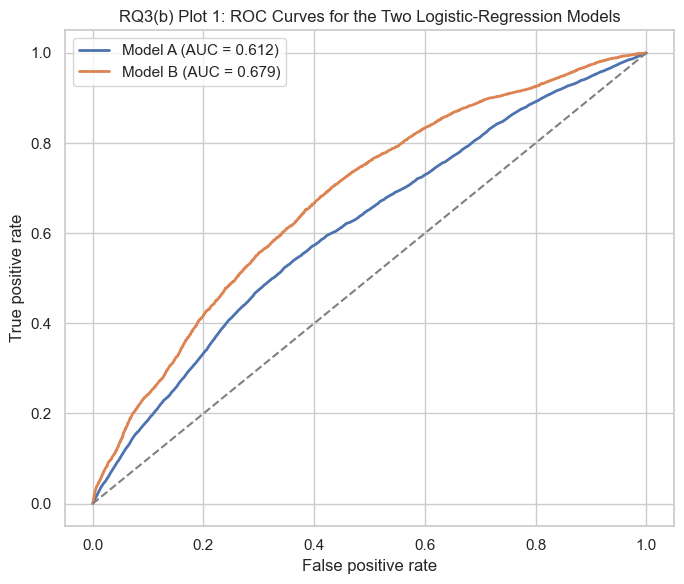

In [ ]:
# RQ3(b)-4) Plot 1: ROC curves for the two logistic-regression models
# ------------------------------------------------------------------
# This plot compares the athlete-only model with the country-adjusted
# model across all classification thresholds.

fpr_a, tpr_a, _ = roc_curve(y_test, proba_a)
fpr_b, tpr_b, _ = roc_curve(y_test, proba_b)

plt.figure(figsize=(7, 6))
plt.plot(fpr_a, tpr_a, linewidth=2, label=f"Model A (AUC = {roc_auc_score(y_test, proba_a):.3f})")
plt.plot(fpr_b, tpr_b, linewidth=2, label=f"Model B (AUC = {roc_auc_score(y_test, proba_b):.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")

plt.title("RQ3(b) Plot 1: ROC Curves for the Two Logistic-Regression Models")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.legend()
plt.tight_layout()
plt.savefig("figures/RQ3/rq3_plot02_roc_curves_for_logistic_regression_models.png", dpi=300, bbox_inches="tight")
plt.show()


### Supplementary model evaluation: Prediction table and confusion matrices

#### What this output shows
This table and the two confusion matrices compare threshold-based prediction performance for the two logistic-regression models at a **0.50 threshold**.

- **Model A** uses age, sex, and sport category.
- **Model B** adds country/team membership.

This supporting output is useful for understanding where the extended model improves or remains limited, even though the main paper-quality figures for RQ3(b) are the **ROC curve** and the **adjusted country/team effects plot**.


### Interpretation

The prediction table and confusion matrices help show **how** the extended model improves prediction at the default **0.50 threshold**.

Accuracy changes very little because the data are highly imbalanced: most athlete-event rows do **not** result in a medal. The more informative comparison is whether **Model B** identifies more true medal-winning rows and whether it improves **recall**, **F1**, or **ROC-AUC** relative to **Model A**.

These outputs are included as supporting evaluation. In the main RQ3(b) discussion, the strongest evidence comes from the **ROC curve** and the **adjusted country/team effects plot**.

#### Limitations
- Confusion matrices depend on the chosen threshold.
- Accuracy alone can be misleading when medal-winning rows are rare.
- These outputs should be interpreted together with ROC-AUC rather than in isolation.


RQ3(b) working shape: (245844, 5)
     age sex    sport_category      team_clean  won_medal
523   60   F  Strength / Mixed       Australia          0
524   60   F  Strength / Mixed       Australia          0
525   60   M  Strength / Mixed     New Zealand          0
526   60   M  Strength / Mixed     New Zealand          0
527   60   M  Strength / Mixed  United Kingdom          0
RQ3(b) prediction-performance table


,Model,Threshold,Accuracy,Precision,Recall,F1_score,ROC_AUC,TN,FP,FN,TP
0,Model A: age + sex + sport_category,0.5,0.859,0.00,0.000,0.000,0.612,52806,0,8655,0
1,Model B: + team_clean,0.5,0.860,0.61,0.018,0.034,0.713,52708,98,8502,153


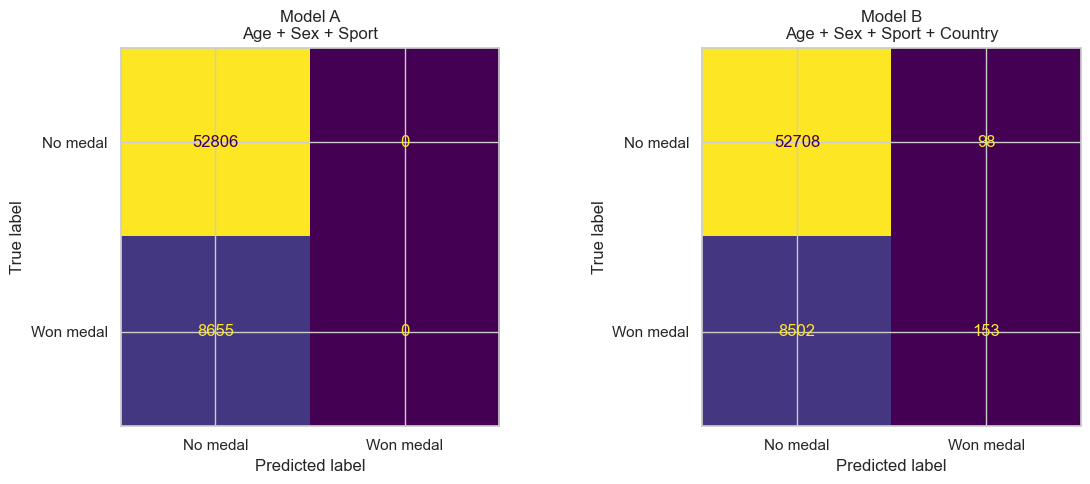

In [ ]:
# RQ3(b)-5) prediction table + confusion matrices for two logistic regression models
# ------------------------------------------------------------------------------
# Model A: age + sex + sport_category
# Model B: age + sex + sport_category + team_clean
#
# This cell is self-contained so you do not need X_test_a / X_test_b from earlier cells.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# -----------------------------------
# 1) Start from the RQ3 dataset
# -----------------------------------
# Assumes rq3a already exists and includes:
# age, sex, sport_category, team_clean, won_medal

rq3b = rq3a.copy()

# Keep only required columns
rq3b = rq3b[["age", "sex", "sport_category", "team_clean", "won_medal"]].dropna().copy()

# Optional: restrict to the same eligible countries used in your earlier RQ3(b) analysis
# Uncomment if you already defined a list like top_countries or eligible_countries
# rq3b = rq3b[rq3b["team_clean"].isin(eligible_countries)].copy()

print("RQ3(b) working shape:", rq3b.shape)
print(rq3b.head())

# -----------------------------------
# 2) Define features and response
# -----------------------------------
y = rq3b["won_medal"]

X_a = rq3b[["age", "sex", "sport_category"]]
X_b = rq3b[["age", "sex", "sport_category", "team_clean"]]

# -----------------------------------
# 3) Train/test split
# -----------------------------------
# Same rows, same target split for both models
X_train_a, X_test_a, y_train, y_test = train_test_split(
    X_a, y,
    test_size=0.25,
    random_state=2010,
    stratify=y
)

X_train_b, X_test_b, _, _ = train_test_split(
    X_b, y,
    test_size=0.25,
    random_state=2010,
    stratify=y
)

# -----------------------------------
# 4) Preprocessing
# -----------------------------------
numeric_features_a = ["age"]
categorical_features_a = ["sex", "sport_category"]

numeric_features_b = ["age"]
categorical_features_b = ["sex", "sport_category", "team_clean"]

preprocess_a = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features_a),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features_a)
    ]
)

preprocess_b = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features_b),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features_b)
    ]
)

# -----------------------------------
# 5) Logistic regression models
# -----------------------------------
model_a = Pipeline(steps=[
    ("preprocess", preprocess_a),
    ("logit", LogisticRegression(max_iter=2000))
])

model_b = Pipeline(steps=[
    ("preprocess", preprocess_b),
    ("logit", LogisticRegression(max_iter=2000))
])

model_a.fit(X_train_a, y_train)
model_b.fit(X_train_b, y_train)

# -----------------------------------
# 6) Predicted probabilities and classes
# -----------------------------------
# Lecture notes: threshold is a decision choice; we use 0.50 as the default.
threshold = 0.50

y_prob_a = model_a.predict_proba(X_test_a)[:, 1]
y_prob_b = model_b.predict_proba(X_test_b)[:, 1]

y_pred_a = (y_prob_a >= threshold).astype(int)
y_pred_b = (y_prob_b >= threshold).astype(int)

# -----------------------------------
# 7) Confusion matrices
# -----------------------------------
cm_a = confusion_matrix(y_test, y_pred_a)
cm_b = confusion_matrix(y_test, y_pred_b)

tn_a, fp_a, fn_a, tp_a = cm_a.ravel()
tn_b, fp_b, fn_b, tp_b = cm_b.ravel()

# -----------------------------------
# 8) Prediction-performance table
# -----------------------------------
perf_table = pd.DataFrame({
    "Model": [
        "Model A: age + sex + sport_category",
        "Model B: + team_clean"
    ],
    "Threshold": [threshold, threshold],
    "Accuracy": [
        accuracy_score(y_test, y_pred_a),
        accuracy_score(y_test, y_pred_b)
    ],
    "Precision": [
        precision_score(y_test, y_pred_a, zero_division=0),
        precision_score(y_test, y_pred_b, zero_division=0)
    ],
    "Recall": [
        recall_score(y_test, y_pred_a, zero_division=0),
        recall_score(y_test, y_pred_b, zero_division=0)
    ],
    "F1_score": [
        f1_score(y_test, y_pred_a, zero_division=0),
        f1_score(y_test, y_pred_b, zero_division=0)
    ],
    "ROC_AUC": [
        roc_auc_score(y_test, y_prob_a),
        roc_auc_score(y_test, y_prob_b)
    ],
    "TN": [tn_a, tn_b],
    "FP": [fp_a, fp_b],
    "FN": [fn_a, fn_b],
    "TP": [tp_a, tp_b]
})

metric_cols = ["Threshold", "Accuracy", "Precision", "Recall", "F1_score", "ROC_AUC"]
perf_table[metric_cols] = perf_table[metric_cols].round(3)

print("RQ3(b) prediction-performance table")
display(perf_table)

# -----------------------------------
# 9) Plot confusion matrices side by side
# -----------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

disp1 = ConfusionMatrixDisplay(
    confusion_matrix=cm_a,
    display_labels=["No medal", "Won medal"]
)
disp1.plot(ax=axes[0], colorbar=False)
axes[0].set_title("Model A\nAge + Sex + Sport")

disp2 = ConfusionMatrixDisplay(
    confusion_matrix=cm_b,
    display_labels=["No medal", "Won medal"]
)
disp2.plot(ax=axes[1], colorbar=False)
axes[1].set_title("Model B\nAge + Sex + Sport + Country")

plt.tight_layout()
plt.savefig("figures/RQ3/rq3_plot03_confusion_matrices_for_two_logistic_models.png", dpi=300, bbox_inches="tight")
plt.show()

### RQ3(b)-5: Plot 2 — Adjusted country/team effects after controlling for athlete characteristics

#### What this plot shows
This plot displays selected country/team effects from **Model B** after controlling for **age, sex, and sport category**.

Each bar is an **adjusted odds ratio** relative to the model’s reference country/team:
- values **above 1** indicate higher adjusted medal odds than the reference country/team,
- values **below 1** indicate lower adjusted medal odds,
- the dashed vertical line at **1** represents no difference from the reference group.


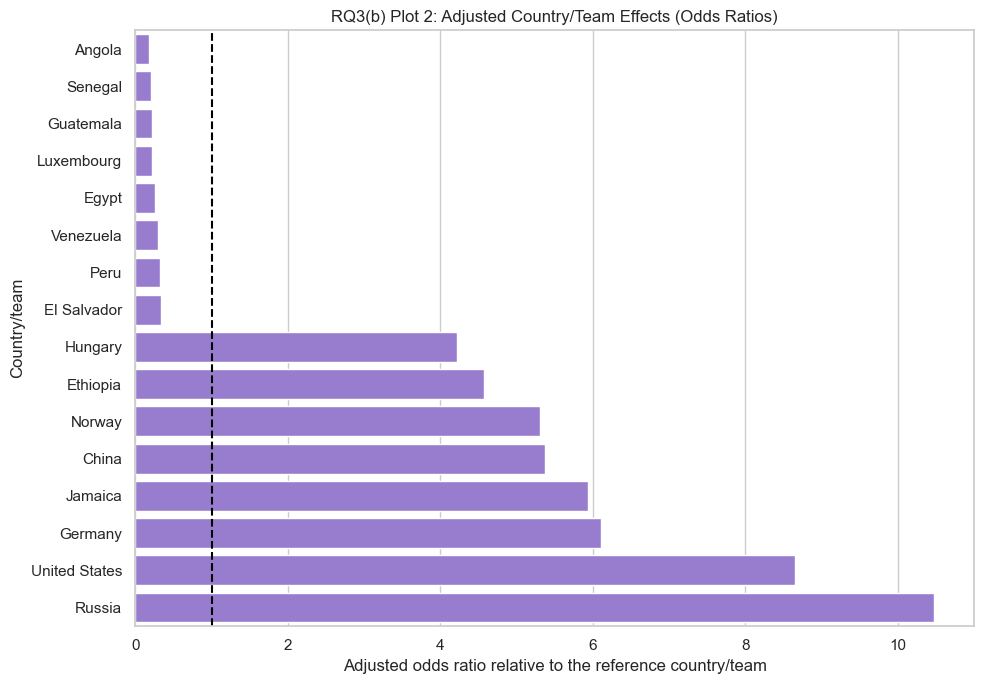

In [ ]:
# RQ3(b)-6) Plot 2: adjusted country/team effects as odds ratios
# -------------------------------------------------------------
# This plot shows which countries remain advantaged or disadvantaged
# after age, sex, and sport category are already included in Model B.

# Get feature names and coefficients from the fitted Model B pipeline
feature_names_b = model_b.named_steps["preprocess"].get_feature_names_out()
coef_b = model_b.named_steps["logit"].coef_[0]

coef_df_b = pd.DataFrame({
    "feature": feature_names_b,
    "coefficient": coef_b
})

# Keep only country/team coefficients and convert them to odds ratios
country_coef = coef_df_b[coef_df_b["feature"].str.contains("team_clean_")].copy()
country_coef["team_clean"] = (
    country_coef["feature"]
    .str.replace("cat__", "", regex=False)
    .str.replace("team_clean_", "", regex=False)
)
country_coef["odds_ratio"] = np.exp(country_coef["coefficient"])

# Show the most negative and most positive adjusted country effects
country_or_plot = pd.concat([
    country_coef.nsmallest(8, "coefficient"),
    country_coef.nlargest(8, "coefficient")
]).drop_duplicates(subset=["team_clean"]).copy()

country_or_plot = country_or_plot.sort_values("odds_ratio")

plt.figure(figsize=(10, 7))
sns.barplot(data=country_or_plot, x="odds_ratio", y="team_clean", color="mediumpurple")
plt.axvline(1.0, linestyle="--", color="black")

plt.title("RQ3(b) Plot 2: Adjusted Country/Team Effects (Odds Ratios)")
plt.xlabel("Adjusted odds ratio relative to the reference country/team")
plt.ylabel("Country/team")
plt.savefig("figures/RQ3/rq3_plot04_adjusted_country_team_effects_odds_ratios.png", dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()

### Interpretation
This plot shows that country/team membership still matters even after controlling for athlete-level characteristics. Some countries have adjusted odds ratios well above 1, which suggests that comparable athletes from those countries have higher predicted medal odds than athletes from the reference country/team. Other countries fall below 1, indicating relatively lower adjusted medal odds.

The main takeaway is that **country-level advantage remains visible after accounting for age, sex, and sport category**. This supports the RQ3(b) result that adding country/team membership improves medal prediction beyond athlete characteristics alone.

#### Limitations
- These odds ratios are interpreted relative to the model’s **reference country/team**, so they are comparative rather than absolute.
- Coefficients may be sensitive to class imbalance and unequal country sample sizes.
- This is an observational model, so the country effects should be interpreted as adjusted associations, not causal effects.


### Conclusion

Overall, the results show that **country/team membership still matters** after controlling for **age, sex, and sport category**. The ROC comparison demonstrates that adding country/team improves predictive performance beyond athlete characteristics alone, while the adjusted odds-ratio plot shows which countries remain relatively advantaged or disadvantaged after that adjustment.

Taken together, these results support the conclusion that athlete characteristics explain part of medal probability, but they do **not** fully explain it. Country/team membership still contributes meaningful additional information to Olympic medal outcomes.


# Appendix

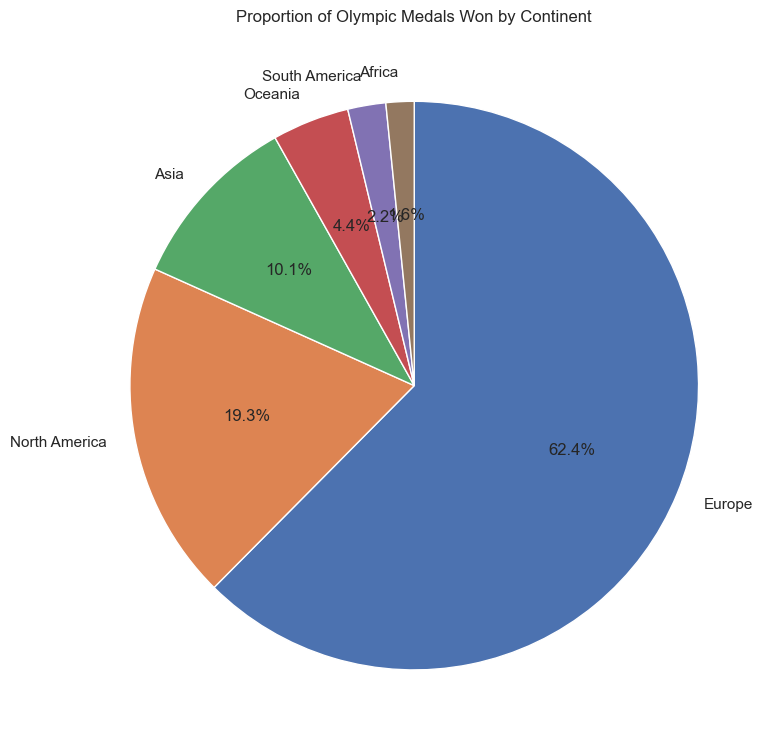

       continent  medal_count    percent
0         Europe        21629  62.432167
1  North America         6683  19.290498
2           Asia         3511  10.134511
3        Oceania         1519   4.384598
4  South America          749   2.161991
5         Africa          553   1.596236


In [ ]:
# Proportion of Olympic Medals Won by Continent
# ---------------------------------------------
# Assumes:
# - your cleaning code has already run
# - df exists
# - df["team"] contains cleaned present-day sovereign country names

import pandas as pd
import matplotlib.pyplot as plt

# Medal-winning rows only
medal_df = df[df["medal"].isin(["Gold", "Silver", "Bronze"])].copy()

# Map countries to continents
continent_map = {
    # Africa
    "Algeria": "Africa", "Angola": "Africa", "Benin": "Africa", "Botswana": "Africa",
    "Burkina Faso": "Africa", "Burundi": "Africa", "Cameroon": "Africa",
    "Cape Verde": "Africa", "Central African Republic": "Africa", "Chad": "Africa",
    "Comoros": "Africa", "Congo": "Africa", "Djibouti": "Africa", "Egypt": "Africa",
    "Equatorial Guinea": "Africa", "Eritrea": "Africa", "Eswatini": "Africa",
    "Ethiopia": "Africa", "Gabon": "Africa", "Gambia": "Africa", "Ghana": "Africa",
    "Guinea": "Africa", "Guinea-Bissau": "Africa", "Ivory Coast": "Africa",
    "Kenya": "Africa", "Lesotho": "Africa", "Liberia": "Africa", "Libya": "Africa",
    "Madagascar": "Africa", "Malawi": "Africa", "Mali": "Africa",
    "Mauritania": "Africa", "Mauritius": "Africa", "Morocco": "Africa",
    "Mozambique": "Africa", "Namibia": "Africa", "Niger": "Africa",
    "Nigeria": "Africa", "Rwanda": "Africa", "Sao Tome and Principe": "Africa",
    "Senegal": "Africa", "Seychelles": "Africa", "Sierra Leone": "Africa",
    "Somalia": "Africa", "South Africa": "Africa", "South Sudan": "Africa",
    "Sudan": "Africa", "Tanzania": "Africa", "Togo": "Africa", "Tunisia": "Africa",
    "Uganda": "Africa", "Zambia": "Africa", "Zimbabwe": "Africa",

    # Asia
    "Afghanistan": "Asia", "Armenia": "Asia", "Azerbaijan": "Asia", "Bahrain": "Asia",
    "Bangladesh": "Asia", "Bhutan": "Asia", "Brunei": "Asia", "Cambodia": "Asia",
    "China": "Asia", "Georgia": "Asia", "India": "Asia", "Indonesia": "Asia",
    "Iran": "Asia", "Iraq": "Asia", "Israel": "Asia", "Japan": "Asia",
    "Jordan": "Asia", "Kazakhstan": "Asia", "Kuwait": "Asia", "Kyrgyzstan": "Asia",
    "Laos": "Asia", "Lebanon": "Asia", "Malaysia": "Asia", "Maldives": "Asia",
    "Mongolia": "Asia", "Myanmar": "Asia", "Nepal": "Asia", "North Korea": "Asia",
    "Oman": "Asia", "Pakistan": "Asia", "Philippines": "Asia", "Qatar": "Asia",
    "Saudi Arabia": "Asia", "Singapore": "Asia", "South Korea": "Asia",
    "Sri Lanka": "Asia", "Syria": "Asia", "Tajikistan": "Asia", "Thailand": "Asia",
    "Timor-Leste": "Asia", "Turkey": "Asia", "Turkmenistan": "Asia",
    "United Arab Emirates": "Asia", "Uzbekistan": "Asia", "Vietnam": "Asia",
    "Yemen": "Asia",

    # Europe
    "Albania": "Europe", "Andorra": "Europe", "Austria": "Europe", "Belarus": "Europe",
    "Belgium": "Europe", "Bosnia and Herzegovina": "Europe", "Bulgaria": "Europe",
    "Croatia": "Europe", "Cyprus": "Europe", "Czech Republic": "Europe",
    "Denmark": "Europe", "Estonia": "Europe", "Finland": "Europe", "France": "Europe",
    "Germany": "Europe", "Greece": "Europe", "Hungary": "Europe", "Iceland": "Europe",
    "Ireland": "Europe", "Italy": "Europe", "Kosovo": "Europe", "Latvia": "Europe",
    "Liechtenstein": "Europe", "Lithuania": "Europe", "Luxembourg": "Europe",
    "Malta": "Europe", "Moldova": "Europe", "Monaco": "Europe", "Montenegro": "Europe",
    "Netherlands": "Europe", "North Macedonia": "Europe", "Norway": "Europe",
    "Poland": "Europe", "Portugal": "Europe", "Romania": "Europe", "Russia": "Europe",
    "San Marino": "Europe", "Serbia": "Europe", "Slovakia": "Europe",
    "Slovenia": "Europe", "Spain": "Europe", "Sweden": "Europe", "Switzerland": "Europe",
    "Ukraine": "Europe", "United Kingdom": "Europe",

    # North America
    "Antigua and Barbuda": "North America", "Bahamas": "North America", "Barbados": "North America",
    "Belize": "North America", "Canada": "North America", "Costa Rica": "North America",
    "Cuba": "North America", "Dominica": "North America", "Dominican Republic": "North America",
    "El Salvador": "North America", "Grenada": "North America", "Guatemala": "North America",
    "Haiti": "North America", "Honduras": "North America", "Jamaica": "North America",
    "Mexico": "North America", "Nicaragua": "North America", "Panama": "North America",
    "Saint Kitts and Nevis": "North America", "Saint Lucia": "North America",
    "Trinidad and Tobago": "North America", "United States": "North America",

    # South America
    "Argentina": "South America", "Bolivia": "South America", "Brazil": "South America",
    "Chile": "South America", "Colombia": "South America", "Ecuador": "South America",
    "Guyana": "South America", "Paraguay": "South America", "Peru": "South America",
    "Suriname": "South America", "Uruguay": "South America", "Venezuela": "South America",

    # Oceania
    "Australia": "Oceania", "Fiji": "Oceania", "New Zealand": "Oceania",
    "Papua New Guinea": "Oceania", "Samoa": "Oceania", "Tonga": "Oceania"
}

# Add continent column
medal_df["continent"] = medal_df["team"].map(continent_map)

# Drop rows that could not be mapped
medal_df = medal_df.dropna(subset=["continent"]).copy()

# Count medal-winning rows by continent
continent_counts = medal_df["continent"].value_counts()

# Pie chart
plt.figure(figsize=(8, 8))
plt.pie(
    continent_counts,
    labels=continent_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    counterclock=False
)
plt.title("Proportion of Olympic Medals Won by Continent")
plt.tight_layout()
plt.savefig("figures/Appendix/appendix_plot03_proportion_of_olympic_medals_won_by_continent.png", dpi=300, bbox_inches="tight")

plt.show()

# Optional table
continent_summary = (
    continent_counts.rename_axis("continent")
    .reset_index(name="medal_count")
)
continent_summary["percent"] = 100 * continent_summary["medal_count"] / continent_summary["medal_count"].sum()

print(continent_summary)